# editing plots

In [ ]:
python /work/jessica.mcdonald/CM1_LETKF_2025/ens.py -e RUN_LETKF/RUN_LETKF.exp -t 2003,05,08,21,40,00 -v W --plotmean

In [1]:
from optparse import OptionParser
import sys
import os
import numpy as np
import datetime as DT 
import netCDF4 as ncdf
import glob
import pylab as P
from datetime import datetime
from src.plot_src.cbook2 import nice_mxmnintvl, nice_clevels
import matplotlib.cm as cm
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from scipy import ndimage
import re

import colormaps as cmaps

import json
import xarray as xr
import datetime as dt
import pandas as pd


from matplotlib.colors import LinearSegmentedColormap, to_rgb

_bin_delta = 1
radar_hgt = 0

_prior_files = "Prior_*"
_plotfilename = "DBZ_ConsistencyRatio"

sec_utime = "seconds since 1970-01-01 00:00:00"


## settings for plots - makes them look nicer
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})



num2obs = {11: ["VR"], 12:["DBZ"], 13:['DBZ0'], 14:['DBZ0_W']}
obs2num  = {'VR':11, 'DBZ':12, 'DBZ0':13, 'DBZ0_W':14}


In [2]:
def smfnc(x):
    return ndimage.gaussian_filter(x, sigma=0.75)
    
# ------------------------------------------------------------------------------------------
# Search functions  each returns a boolean array of T/F with the same dimensions as field

def getIndexVariable(field, variable):
    return (field == variable)
    
def getIndexGreaterThan(field, value):
    return ( field > value )
    
def getIndexLessThan(field, value):
    return ( field < value )
    
def getIndexGreaterThanOrEqual(field, value):
    return ( field >= value )
    
def getIndexLessThanOrEqual(field, value):
    return ( field <= value )

def getIndexEqual(field, value):
    return ( field == value )

def getIndexNotEqual(field, value):
    return ( field != value )

def get_stats_timeseries(experiment_location, only_pos_dbz=True, variable='REF', full_field=False, dz=2000):
    '''experiment_location = path to the .exp file
       only_pos_dbz = if True, then only >10 dBZ is inluded in calculations (innovations will still include all data)
       variable = REFL or DBZ 
       full_field = if True, returns 2d field (x=time, y=height).
       dz is the size of the vertical bins'''

    if variable !='REF':
        only_pos_dbz=False
    
    dirname = os.path.join(experiment_location,_prior_files)
    #plotfilename='DBZ_CR'
    #noshow=True

    file_list = glob.glob(dirname)
    file_list = sorted(file_list,key=os.path.getmtime)

    bin_delta = _bin_delta

    nbins     = len(file_list) // bin_delta
    CR_T      = np.zeros((nbins))
    IN_T      = np.zeros((nbins))
    RMSI_T    = np.zeros((nbins))
    Spread_T  = np.zeros((nbins))

    if full_field:
        print('RETURNING 2D FIELDS')
        zbins    = dz*np.arange(int(8000/dz))
        print(zbins)
        CR_T     = np.zeros((zbins.size,nbins))
        IN_T     = np.zeros((zbins.size,nbins))
        RMSI_T   = np.zeros((zbins.size,nbins))
        Spread_T = np.zeros((zbins.size,nbins))

    datebins = []
    secsbins = []
    m = -1

    for n, file in enumerate(file_list):

        f = ncdf.Dataset(file)

        if n % bin_delta == 0:
            HxfL,valueL,depL,errorL,secsL,zL,kindL = [],[],[],[],[],[],[]

        valueL.append(f.variables["value"][:])
        HxfL.append(f.variables["Hxf"][:]) #hxf is the model value at the location of that ob
        zL.append(f.variables["z"][:] - radar_hgt)
        depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] ) #hxfbar is the mean model values at that location
        secsL.append(f.variables["secs"][:])
        errorL.append(np.sqrt(f.variables["error"][:])) # error is the standard deviation
        kindL.append(ncdf.chartostring(f.variables["type"][:]))

        if n % bin_delta == bin_delta-1:
            Hxf   = np.concatenate(HxfL, axis=0)
            value = np.concatenate(valueL, axis=0)
            z     = np.concatenate(zL, axis=0)
            dep   = np.concatenate(depL, axis=0)
            secs  = np.concatenate(secsL, axis=0)
            error = np.concatenate(errorL, axis=0)
            kind  = np.concatenate(kindL, axis=0)
            datebins.append(DT.datetime.utcfromtimestamp(secs.mean()))

            m+=1

            index_kind  = getIndexVariable(kind,variable)

            #### do a 1D timeseries for each variable
            if full_field == False: 
                if only_pos_dbz & ((variable=='REF')):
                    index_pos   = getIndexGreaterThanOrEqual(value,10.0)
                    index       = index_kind & index_pos
                else:
                    index = index_kind
           
                if np.sum(index == True) > 2: 
                    
                    d           = dep[index] # innovation
                    obs_var     = error[index]
                    Hxftmp      = Hxf[index,:]
                    Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean() 
                    inno_var    = np.mean((d - d.mean())**2) 
                    RMSI_T[m]   = np.mean(np.sqrt((d - d.mean())**2))
                    
                    Spread_T[m] = np.sqrt((obs_var[1]**2 + Hxf_var))
                    CR_T[m]     = (obs_var[1]**2 + Hxf_var) / inno_var # same thing as total spread squared / RMSI sqared
    
                    # for now, calculate innovations WITHOUT a positive DBZ filter (if you're using DBZ)
                    if only_pos_dbz:
                        d        = dep[index_kind] # innovation
                        IN_T[m]  = d.mean()
                    else:
                        IN_T[m]  = d.mean()

            #### return 2D fields
            else:
                for k in np.arange(zbins.size-1):
                    index1                = getIndexGreaterThanOrEqual(z, zbins[k])
                    index2                = getIndexLessThan(z, zbins[k+1])
                    if only_pos_dbz & ((variable=='REF')):
                        index_pos   = getIndexGreaterThanOrEqual(value,10.0)
                        index             = index_kind & index1 & index2 & index_pos
                    else:
                        index             = index_kind & index1 & index2
        
                    if np.sum(index == True) > 2: 
                        d             = dep[index]
                        obs_var       = error[index]
                        Hxftmp        = Hxf[index,:]
                        Hxf_var       = Hxftmp.var(ddof=1, axis=1).mean()
                        inno_var      = np.mean((d - d.mean())**2)
                        CR_T[k,m]     = (obs_var[1]**2 + Hxf_var) / inno_var
                        RMSI_T[k,m]   = np.mean(np.sqrt((d - d.mean())**2))
                        Spread_T[k,m] = np.sqrt((obs_var[1]**2 + Hxf_var))
                        if only_pos_dbz:
                            d         = dep[index_kind & index1 & index2] # innovation
                            IN_T[k,m] = d.mean()
                        else:
                            IN_T[k,m] = d.mean()
                            
        f.close()

    if full_field:
        datebins = [datebins, zbins]

    return datebins, CR_T, IN_T, Spread_T, RMSI_T


def format_time_ticks(ax, dates, approx_number_of_ticks=8,  tick_format='%H:%M', rotation=30, fontsize=14, time_buffer=3, minute_interval=0):
    ''' This does basic date ormatting to help clean up the plot cells
    setting minute_interval to anything other than 0 will override approx_number_of_ticks. '''

    start, end = dates[0].replace(second=0, microsecond=0), dates[-1].replace(second=0, microsecond=0)
    ax.set_xlim(start-DT.timedelta(minutes=time_buffer), end+DT.timedelta(minutes=time_buffer))

    if minute_interval == 0:
        minute_interval = 5*round((end-start).seconds/(approx_number_of_ticks*60*5)) #find the best interval divisble by 5 based on nticks

    ticks = np.arange(start, end+DT.timedelta(minutes=minute_interval), DT.timedelta(minutes=minute_interval))
    ax.set_xticks(ticks, [pd.to_datetime(t).strftime(tick_format) for t in ticks], rotation=30, fontsize=fontsize)

    
def CR_cmap():
    col1 = list(plt.cm.YlGn(np.linspace(0,.68, 10)))
    col2 = list(plt.cm.BuGn(np.linspace(0,.7, 10))[::-1])
    col1.extend(col2)
    clist = [to_rgb(c) for c in col1[::-1]]
    i1,i2 = 9,11
    clist[i1:i2] = np.array(clist[i1:i2])*1.18
    cmap = LinearSegmentedColormap.from_list("CR", clist, 20)
    return cmap

def interweave(a,b, time):
    ''' combines equal length lists a and b (every other) and doubles the time array to [t1,t1,t2,t2, etc
    this creates the innovation plot that shows prior and posterior innovations'''

    new = [None]*(len(time)*2)
    new[::2] = a
    new[1::2] = b
    
    new_time = [None]*(len(time)*2)
    new_time[::2] =time
    new_time[1::2] = time

    return new, new_time

def get_stats_times(var, exp):
    '''var is the obs variable you want, exp is the base_dir with the AllPrior_Post.nc file'''
    ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)
    times = [pd.Timestamp(t) for t in ds.time.values]    
    val = get_var(ds, 'value', var)
    
    Hxfbar = get_var(ds, 'Hxfbar', var)
    Hxf = get_var(ds, 'Hxf', var)
    
    Hxfbar_post = get_var(ds, 'Hxfbar_post', var)
    Hxf_post = get_var(ds, 'Hxf_post', var)
    
    obs_var = get_var(ds, 'error',var) ### NOTE - THIS IS ALREADY SQUARED!

    d = val - Hxfbar ## identical
    inno = np.nanmean((d),axis=1) ##identical
    
    d_post = val-Hxfbar_post
    inno_post = np.nanmean((d_post),axis=1) 
    
    Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical
    inno_var = np.nanmean((d-np.nanmean(d, axis=1)[:,np.newaxis])**2, axis=1) ## identical
    
    rmsi = np.nanmean(np.sqrt((d-np.nanmean(d, axis=1)[:,np.newaxis])**2), axis=1) ##identical
    rmsi_post = np.nanmean(np.sqrt((d_post-np.nanmean(d_post, axis=1)[:,np.newaxis])**2), axis=1) 
    
    spread = np.sqrt(np.nanmax(obs_var) + Hxf_var)
    crt = (np.nanmax(obs_var) + Hxf_var) / inno_var 

    new_inno, new_time = interweave(inno, inno_post, times)
    new_rmsi, new_time = interweave(rmsi, rmsi_post, times)

    return times, new_time, new_inno, crt,spread, new_rmsi
    

def get_ds(myds, kind, t, mem=None):

    ''' this gets you all the data for single data type at a single time
        you cannot get the full dataset for multiple times and multiple variables'''

    kindID = obs2num[kind]
    ds = myds.copy()
    
    if mem!= None:
        ds = ds.isel(ne=slice(mem,mem+1))

    ds = ds.isel(t=slice(t,t+1))
    
    ds = ds.isel(n=ds[kind].values[0])
    return ds
   


def get_var(myds, var, kind, t=None, tf=None, mem=None, keep_dim=True, drop_outliers=True, drop_inliers=False):
    ''' returns a single variable. for a single data type. Keep_dim means you keep the time dimension.
        if t == None, whole dataset returned. if mem=None, all members returned (and dimensions are retained)
        if t!= None but tf == None, then only a single index (t) is returned. Else, a slice between t and tf is returned.'''

    ds = myds.copy()

    if drop_outliers:
        variable = ds[var].values
        variable[ds.outlier.values>3] = np.nan
        if drop_inliers:
            variable[ds.outlier.values<0.25] = np.nan

        if ((var== 'Hxf') | (var== 'Hxf_post')):
            ds[var] = (('t', 'n', 'ne'), variable)
        else:
            ds[var] = (('t', 'n'), variable)
    
    if mem!= None:
        ds = ds.isel(ne=slice(mem,mem+1))
    
    if t!= None:
        if tf == None:tf = t+1
        ds = ds.isel(t=slice(t,tf))
    
    if len(ds.t)==1:
        ds = ds.isel(n=ds[kind].values[0])
        mydata = ds[var].values
        mydata = mydata[np.isnan(mydata) == False]
    
    if (len(ds.t)>1) & (keep_dim==False):
        mydata = ds[var].values[ds[kind].values]
        mydata = mydata[np.isnan(mydata) == False]
    
    
    if (len(ds.t)>1) & (keep_dim) & ((var!= 'Hxf') & (var!= 'Hxf_post')):  
        temp = []
        sizes = []
    
        mydata = np.zeros([len(ds.t), 100000])*np.nan
    
        for i in range(len(ds.t)):
           
            v = ds[var].values[i][ds[kind].values[i]]
            sizes.append(len(v))
            mydata[i, :len(v)] = v
        
        mydata = mydata[:,:np.nanmax(sizes)]
    
    if (len(ds.t)>1) & (keep_dim) & ((var== 'Hxf') | (var== 'Hxf_post')) :  
        temp = []
        sizes = []
    
        if mem !=None: mydata = np.zeros([len(ds.t), 100000])*np.nan
        else:  mydata = np.zeros([len(ds.t), 100000, len(ds.ne)])*np.nan
        for i in range(len(ds.t)):
            for n in range(len(ds.ne)):
                v = ds[var].values[i,:,n][ds[kind].values[i]]
                sizes.append(len(v))
                mydata[i, :len(v), n] = v
        
        mydata = mydata[:,:np.nanmax(sizes)]
        

    return np.array(mydata)
    
def get_stats_times(var, exp):
    '''var is the obs variable you want, exp is the base_dir with the AllPrior_Post.nc file'''
    ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)
    #times = [pd.Timestamp(t) for t in ds.time.values] 
    
    with open(os.path.join(exp, os.path.basename(exp)+'.exp'), 'rb') as f: exper = json.load(f)
    start = DT.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')
    times = [(pd.Timestamp(t)-start).seconds/60 for t in ds.time.values]     
    
    val = get_var(ds, 'value', var)
    
    Hxfbar = get_var(ds, 'Hxfbar', var)
    Hxf = get_var(ds, 'Hxf', var)
    
    Hxfbar_post = get_var(ds, 'Hxfbar_post', var)
    Hxf_post = get_var(ds, 'Hxf_post', var)
    
    obs_var = get_var(ds, 'error',var) ### NOTE - THIS IS ALREADY SQUARED!

    d = val - Hxfbar ## identical

    if var =='DBZ0':
        # mask = (d!=0.0)
        # d = d[mask]
        d[d==0.0] = np.nan
        
    inno = np.nanmean((d),axis=1) ##identical
    
    d_post = val-Hxfbar_post
    inno_post = np.nanmean((d_post),axis=1) 
    
    Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical
    inno_var = np.nanmean((d-np.nanmean(d, axis=1)[:,np.newaxis])**2, axis=1) ## identical

    Hxf_var_post = np.nanmean(np.nanvar(Hxf_post, ddof=1, axis=2),axis=1) ##identical
    
    rmsi      = np.nanmean(np.sqrt((d-np.nanmean(d, axis=1)[:,np.newaxis])**2), axis=1) ##identical
    rmsi_post = np.nanmean(np.sqrt((d_post-np.nanmean(d_post, axis=1)[:,np.newaxis])**2), axis=1) 
    
    spread      = np.sqrt(np.nanmax(obs_var) + Hxf_var)
    spread_post = np.sqrt(np.nanmax(obs_var) + Hxf_var_post)
    
    crt = (np.nanmax(obs_var) + Hxf_var) / inno_var 

    return times, inno, inno_post, crt,spread,spread_post, rmsi, rmsi_post


import warnings

warnings.filterwarnings(action='ignore', message='Mean of empty slice')
warnings.filterwarnings(action='ignore', message='Degrees of freedom <= 0 for slice')


from matplotlib.legend_handler import HandlerBase


class AnyObjectHandler(HandlerBase):
    
    def create_artists(self, legend, orig_handle, x0, y0, width, height, fontsize, trans):

        if len(orig_handle) == 3:

            l1 = plt.Line2D([x0,y0+width], [0.3*height,0.3*height], color=orig_handle[0], linewidth=orig_handle[2])
            l2 = plt.Line2D([x0,y0+width], [0.7*height,0.7*height], color=orig_handle[0], linewidth=orig_handle[2], linestyle=orig_handle[1])
            
            return [l1, l2]
        if len(orig_handle) == 4:
            l1 = plt.Line2D([x0,y0+width], [0.5*height,0.5*height], color=orig_handle[0], linewidth=orig_handle[2], linestyle=orig_handle[1])
            return [l1]

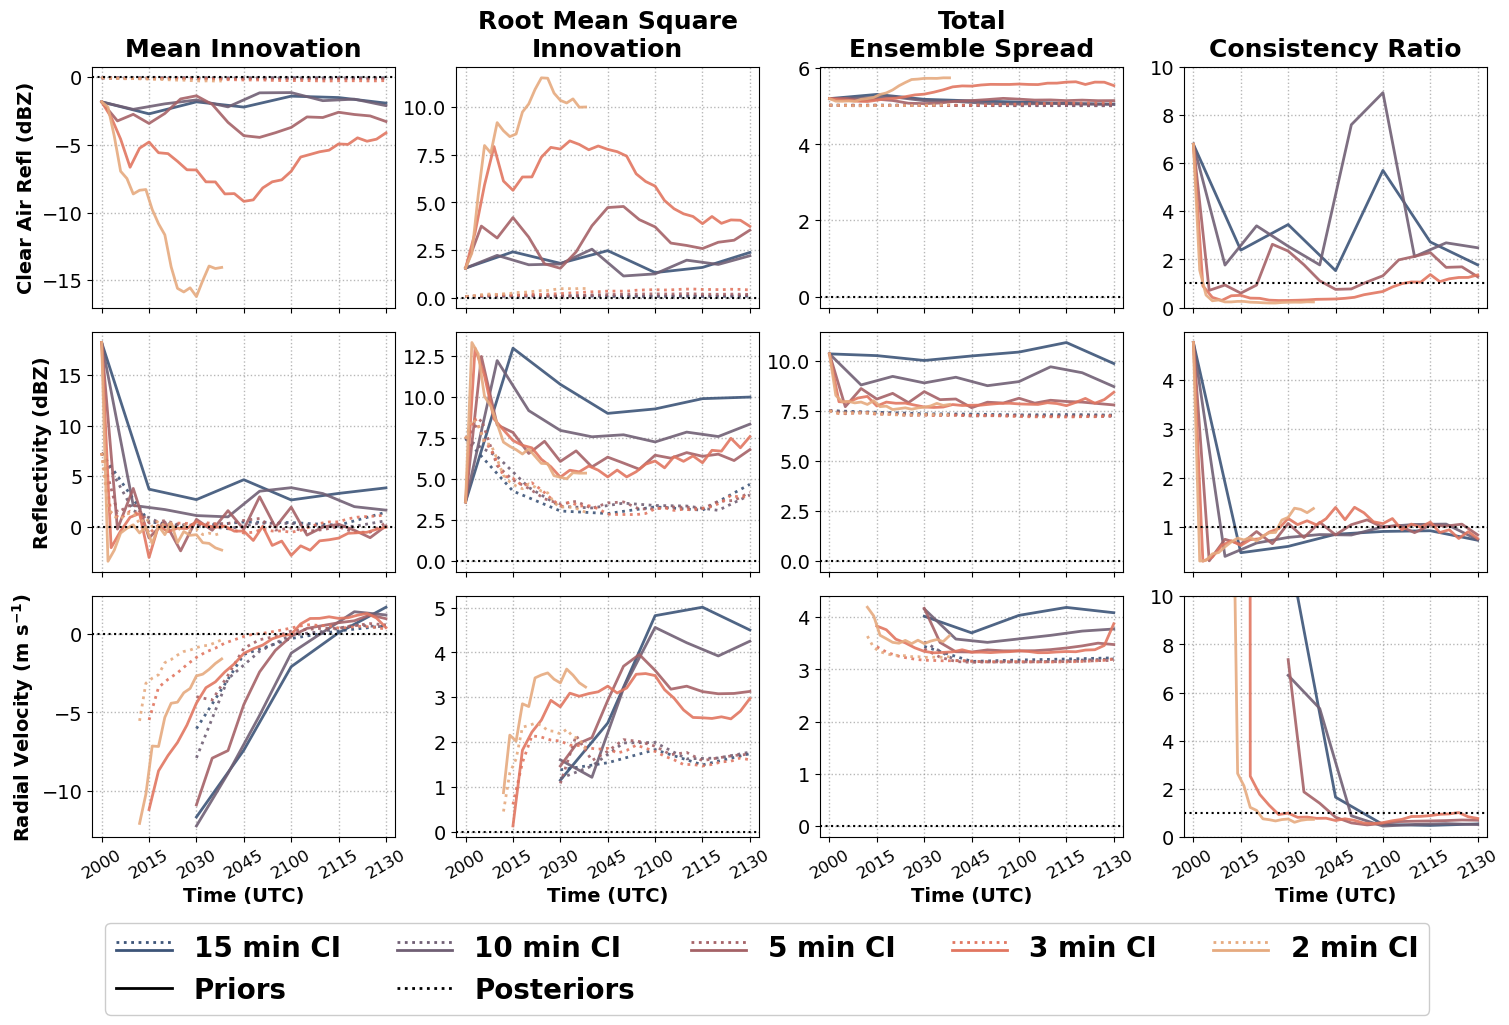

In [504]:


exps = ['/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_15min',
       '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min',
       '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_5min',
        '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min','/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_2min']



obs = [ 'DBZ0', 'DBZ', 'VR']
labels = [ '15 min CI', '10 min CI', '5 min CI', '3 min CI', '2 min CI']
#colors = cmaps.lipari(np.linspace(.24, .85, len(exps)))

colors = cmaps.lipari(np.linspace(.15, .85, len(exps)))

if len(exps) == 5:
    colors = cmaps.lipari([.2,.35, .5, .65, .8])

fig,axes = plt.subplots(3,4, figsize=(18,10), sharex=True)


axes[0,0].set_title('Mean Innovation', weight='bold', y=1.01)
axes[0,1].set_title('Root Mean Square\nInnovation', weight='bold', y=1.01)
axes[0,2].set_title('Total\nEnsemble Spread', weight='bold', y=1.01)
axes[0,3].set_title('Consistency Ratio', weight='bold', y=1.01)

max_CR=[]

for i,exp in enumerate(exps):
    color = colors[i]
    for ii,var in enumerate(obs):

        #dates,dates_n, IN, CR, SPRD, RMSI = get_stats_times(var, exp)
        dates, IN,INpost, CR, SPRD,SPRDpost, RMSI, RMSIpost = get_stats_times(var, exp)
        
        axes[ii,0].plot(dates, IN, lw=2, alpha=0.9,color=color,label=labels[i])
        axes[ii,0].plot(dates, INpost, lw=2, alpha=0.9,ls=':', color=color)
        
        axes[ii,1].plot(dates, RMSI, lw=2, alpha=0.9,color=color,label=labels[i])
        axes[ii,1].plot(dates, RMSIpost, lw=2, alpha=0.9,ls=':',color=color)
        
        axes[ii,2].plot(dates, SPRD, lw=2, alpha=0.9,color=color,label=labels[i])
        axes[ii,2].plot(dates, SPRDpost, lw=2, alpha=0.9,ls=':',color=color)
        
        axes[ii,3].plot(dates, CR,   lw=2, alpha=0.9,color=color,label=labels[i])

dates, IN,INpost, CR, SPRD,SPRDpost, RMSI, RMSIpost = get_stats_times(var, exps[0])
# formatting
plt.subplots_adjust(hspace=0.1)
for ax in axes[-1,:].flatten():
    format_time_ticks(ax, dates, fontsize=12, approx_number_of_ticks=6, tick_format='%H%M')
    ax.set_xlabel('Time (UTC)')
for ax in axes.flatten():
    ax.grid(ls=':', alpha=0.7)
for ax in axes[:,[0,1,2]].flatten():
    ax.axhline(0, ls=':', color='k')
for ax in axes[:,3].flatten():
    ax.axhline(1, ls=':', color='k')


axes[0,3].set_ylim(0, 10)
axes[2,3].set_ylim(0, 10)

if "DBZ0_W" in obs:
    axes[0,0].set_ylabel('Clear Air Refl (dBZ->W)', weight='bold');
else:
    axes[0,0].set_ylabel('Clear Air Refl (dBZ)', weight='bold');

axes[1,0].set_ylabel('Reflectivity (dBZ)', weight='bold');
axes[2,0].set_ylabel(r'Radial Velocity (m s$\mathbf{^{-1}}$)', weight='bold');

_, labels = plt.gca().get_legend_handles_labels()

llen = len(exps)

if llen > 1:

    bbox = (0.5, -0.082)

    handles = []
    for i in range(llen): 
        handles.append((colors[i], ':',2))
        
    new_labels = ['']*llen*2
    new_handles = [('w', '-', 2, 'textonly')]*llen*2
    
    for i in np.arange(0, llen*2, 2):
        new_labels[i] = labels[int(i/2)]
        new_handles[i] = handles[int(i/2)]
        if i == 0:
            new_labels[1] = 'Priors'
            new_handles[1] = ('k', '-', 2, 'prior')
        if i == 2:
            new_labels[3] = 'Posteriors'
            new_handles[3] = ('k', ':', 2, 'post')

else:

    bbox = (0.5, -0.032)
    labels.extend(['Prior','Posterior'])
    handles.extend([('k', '-', 2, 'prior'), ('k', ':', 2, 'post')])
    new_labels, new_handles = labels, handles
    llen=3

leg = fig.legend(new_handles, new_labels,  handler_map={tuple:AnyObjectHandler()},
           prop={'size':20, 'weight':'bold'}, loc='lower center', ncol=llen, bbox_to_anchor=bbox,)


In [12]:
os.path.basename(exp)

'CI_3min_inlier'

/tmp/ipykernel_1338792/1948321121.py:353: RuntimeWarning: divide by zero encountered in divide
  crt = (np.nanmax(obs_var) + Hxf_var) / inno_var


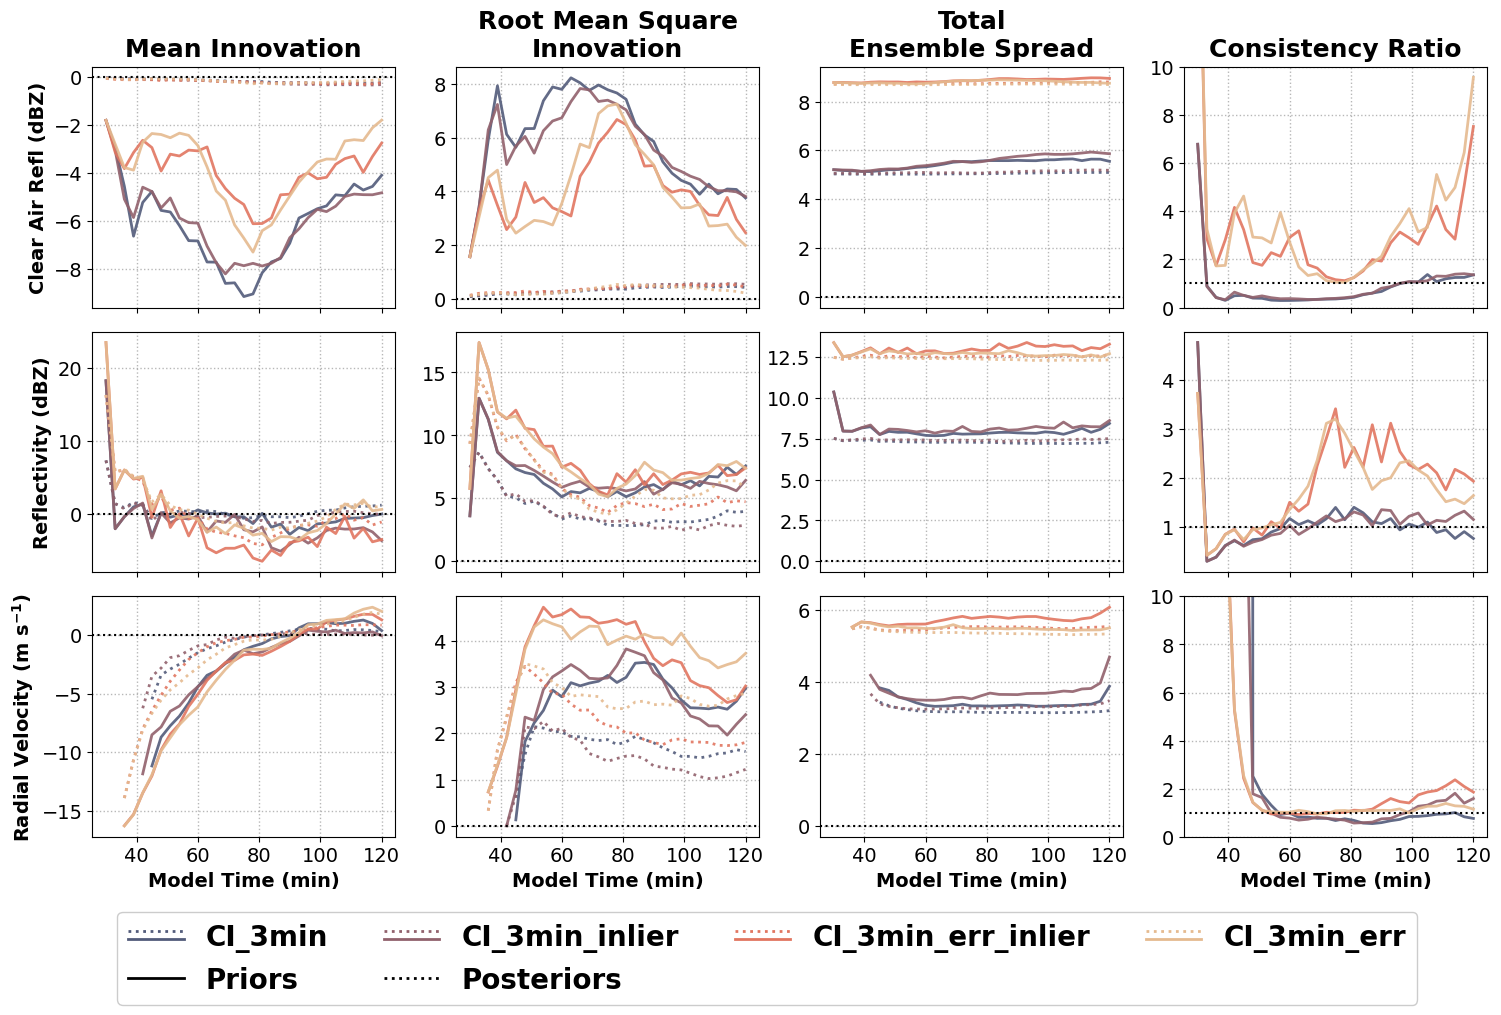

In [80]:


# exps = [
#        '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min',
#     '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_inlier','/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_err','/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_err_inlier'
#        ]


obs = [ 'DBZ0', 'DBZ', 'VR']
#labels = [ '3 min CI', '3 min CI - inlier', '3 min CI - larger error', '3 min CI - larger error + inlier']

exps = ['CI_5min', 'CI_5min_err','CI_3min', 'CI_3min_err']
exps = ['CI_3min', 'CI_3min_inlier', 'CI_3min_err_inlier','CI_3min_err']
#exps = ['CI_10min', 'CI_10min_inlier']

#colors = cmaps.lipari(np.linspace(.24, .85, len(exps)))

colors = cmaps.lipari(np.linspace(.25, .85, len(exps)))

fig,axes = plt.subplots(3,4, figsize=(18,10), sharex=True)


axes[0,0].set_title('Mean Innovation', weight='bold', y=1.01)
axes[0,1].set_title('Root Mean Square\nInnovation', weight='bold', y=1.01)
axes[0,2].set_title('Total\nEnsemble Spread', weight='bold', y=1.01)
axes[0,3].set_title('Consistency Ratio', weight='bold', y=1.01)

max_CR=[]

for i,exp in enumerate(exps):
    color = colors[i]
    fpath  = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'+exp

    for ii,var in enumerate(obs):

        

        #dates,dates_n, IN, CR, SPRD, RMSI = get_stats_times(var, exp)
        dates, IN,INpost, CR, SPRD,SPRDpost, RMSI, RMSIpost = get_stats_times(var, fpath)
        
        axes[ii,0].plot(dates, IN, lw=2, alpha=0.9,color=color,label=exp)
        axes[ii,0].plot(dates, INpost, lw=2, alpha=0.9,ls=':', color=color,label=exp)
        
        axes[ii,1].plot(dates, RMSI, lw=2, alpha=0.9,color=color,label=exp)
        axes[ii,1].plot(dates, RMSIpost, lw=2, alpha=0.9,ls=':',color=color,label=exp)
        
        axes[ii,2].plot(dates, SPRD, lw=2, alpha=0.9,color=color,label=exp)
        axes[ii,2].plot(dates, SPRDpost, lw=2, alpha=0.9,ls=':',color=color,label=exp)
        
        axes[ii,3].plot(dates, CR,   lw=2, alpha=0.9,color=color,label=exp)

dates, IN,INpost, CR, SPRD,SPRDpost, RMSI, RMSIpost = get_stats_times(var, f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'+exps[0])
# formatting
plt.subplots_adjust(hspace=0.1)
for ax in axes[-1,:].flatten():
    #format_time_ticks(ax, dates, fontsize=12, approx_number_of_ticks=6, tick_format='%H%M')
    ax.set_xlabel('Model Time (min)')
for ax in axes.flatten():
    ax.grid(ls=':', alpha=0.7)
for ax in axes[:,[0,1,2]].flatten():
    ax.axhline(0, ls=':', color='k')
for ax in axes[:,3].flatten():
    ax.axhline(1, ls=':', color='k')


axes[0,3].set_ylim(0, 10)
axes[2,3].set_ylim(0, 10)

if "DBZ0_W" in obs:
    axes[0,0].set_ylabel('Clear Air Refl (dBZ->W)', weight='bold');
else:
    axes[0,0].set_ylabel('Clear Air Refl (dBZ)', weight='bold');

axes[1,0].set_ylabel('Reflectivity (dBZ)', weight='bold');
axes[2,0].set_ylabel(r'Radial Velocity (m s$\mathbf{^{-1}}$)', weight='bold');

_, labels = plt.gca().get_legend_handles_labels()

llen = len(exps)

if llen > 1:

    bbox = (0.5, -0.072)

    handles = []
    for i in range(llen): 
        handles.append((colors[i], ':',2))
        
    new_labels = ['']*llen*2
    new_handles = [('w', '-', 2, 'textonly')]*llen*2
    
    for i in np.arange(0, llen*2, 2):
        new_labels[i] = labels[int(i/2)]
        new_handles[i] = handles[int(i/2)]
        if i == 0:
            new_labels[1] = 'Priors'
            new_handles[1] = ('k', '-', 2, 'prior')
        if i == 2:
            new_labels[3] = 'Posteriors'
            new_handles[3] = ('k', ':', 2, 'post')

else:

    bbox = (0.5, -0.032)
    labels.extend(['Prior','Posterior'])
    handles.extend([('k', '-', 2, 'prior'), ('k', ':', 2, 'post')])
    new_labels, new_handles = labels, handles
    llen=3

leg = fig.legend(new_handles, new_labels,  handler_map={tuple:AnyObjectHandler()},
           prop={'size':20, 'weight':'bold'}, loc='lower center', ncol=llen, bbox_to_anchor=bbox,)


In [24]:
fpath

'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_err'

In [90]:
var='DBZ'

def plot_obs_stats(exp, var, inlier=False):
    ds = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/AllPrior_Post.nc", decode_timedelta=True)
    times = [pd.Timestamp(t) for t in ds.time.values]    
    val = get_var(ds, 'value', var, drop_inlier=inlier)
    
    Hxfbar = get_var(ds, 'Hxfbar', var,drop_inlier=inlier)
    Hxf = get_var(ds, 'Hxf', var, drop_inlier=inlier)
    
    Hxfbar_post = get_var(ds, 'Hxfbar_post', var, drop_inlier=inlier))
    Hxf_post = get_var(ds, 'Hxf_post', var, drop_inlier=inlier))
    
    obs_var = get_var(ds, 'error',var, drop_inlier=inlier)) ### NOTE - THIS IS ALREADY SQUARED!
    
    outlier = get_var(ds, 'outlier', var, drop_inlier=inlier))
    
    d = val - Hxfbar ## identical
    
    # if var =='DBZ0':
    #     # mask = (d!=0.0)
    #     # d = d[mask]
    #     d[d==0.0] = np.nan
        
    inno = np.nanmean((d),axis=1) ##identical
    
    d_post = val-Hxfbar_post
    inno_post = np.nanmean((d_post),axis=1) 
    
    Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical
    inno_var = np.nanmean((d-np.nanmean(d, axis=1)[:,np.newaxis])**2, axis=1) ## identical
    
    Hxf_var_post = np.nanmean(np.nanvar(Hxf_post, ddof=1, axis=2),axis=1) ##identical
    
    rmsi      = np.nanmean(np.sqrt((d-np.nanmean(d, axis=1)[:,np.newaxis])**2), axis=1) ##identical
    rmsi_post = np.nanmean(np.sqrt((d_post-np.nanmean(d_post, axis=1)[:,np.newaxis])**2), axis=1) 
    
    spread      = np.sqrt(np.nanmax(obs_var) + Hxf_var)
    spread_post = np.sqrt(np.nanmax(obs_var) + Hxf_var_post)
    
    crt = (np.nanmax(obs_var) + Hxf_var) / inno_var 
    
    # obs counts
    outlier = get_var(ds, 'outlier', var, drop_outliers=False)

    if inlier == False:
        Nobs_reject = np.count_nonzero(outlier > 3, axis=1).astype(float)
        Nobs_assim = np.count_nonzero(outlier <= 3, axis=1).astype(float)
        Nobs = Nobs_reject+Nobs_assim
        
        Nobs_reject[np.where(Nobs_reject == 0.0)] = np.nan
        Nobs_assim[Nobs_assim == 0.0] = np.nan
    if inlier:
        
        Nobs_out= np.count_nonzero(outlier > 3, axis=1).astype(float)
        Nobs_in = np.count_nonzero(outlier < 0.25, axis=1).astype(float)
        Nobs = np.count_nonzero(np.isnan(outlier)==False, axis=1).astype(float)
        Nobs_reject = Nobs_out+Nobs_in
        
        Nobs_assim = Nobs - Nobs_reject
    
    
    obs_err = np.sqrt(np.nanmax(obs_var))
    
    c = cmaps.ember(np.linspace(.3, .8, 3))
    c = cmaps.torch(np.linspace(.3, .8, 3))
    c = cmaps.sunburst(np.linspace(.2, .7, 3))

    c = cmaps.lipari(np.linspace(.24, .8, 3))
    
    fig,axes=plt.subplots(2,2,figsize=(14,10), sharex=True)
    
    #----------------------
    axes[0,0].plot(times, inno,      lw=2,color=c[0],label='prior innov.' )
    axes[0,0].plot(times, inno_post, lw=2,ls='--', color=c[0], label='post innov.' )
    
    axes[0,0].plot(times, rmsi,     lw=2, color=c[1], label='prior rmsi')
    axes[0,0].plot(times, rmsi_post,lw=2, color=c[1],ls='--', label='post rmsi')
    
    axes[0,0].plot(times, spread,     lw=2, color=c[2], label='prior spread')
    axes[0,0].plot(times, spread_post,lw=2, color=c[2],ls='--', label='post spread')
    
    pl = axes[0,0].plot(times, [obs_err]*len(times), color='k', lw=3, alpha=0.3)
    #----------------------
    
    axes[0,1].plot(times, crt, color=c[0], lw=3)
    axes[0,1].axhline(1, ls=':', color='k')
    #----------------------

    axes[1,0].plot(times, [obs_err]*len(times), label='ob error', color='k', lw=3, alpha=0.3)
    axes[1,0].plot(times, inno, color=c[0],     lw=2,label='y - Hxf')
    axes[1,0].plot(times, np.sqrt(Hxf_var),     lw=2, color=c[1],label='stdev Hxf')
    #----------------------
    
    axes[1,1].plot(times,Nobs,        color=c[0], lw=4, label='Total')
    axes[1,1].plot(times,Nobs_assim,  color=c[2], lw=2,label='Assimilated')
    axes[1,1].plot(times,Nobs_reject, color=c[1], lw=2,label='Rejected')
    
    
    ## legends
    axes[0,0].legend(fontsize=12,ncol=3, handlelength=1.5, loc='upper center', bbox_to_anchor=(.5, 1.15))
    axes[1,0].legend(fontsize=14,ncol=3, handlelength=1.5, loc='upper center', bbox_to_anchor=(.5, 1.1))
    axes[1,1].legend(fontsize=14,ncol=3, handlelength=1.5, loc='upper center', bbox_to_anchor=(.5, 1.1))
    
    
    # formatting and labels
    format_time_ticks(axes[1,0], times, fontsize=12, approx_number_of_ticks=7, tick_format='%H%M')
    format_time_ticks(axes[1,1], times, fontsize=12, approx_number_of_ticks=7, tick_format='%H%M')
    plt.subplots_adjust(hspace=0.13)
    
    axes[0,0].set_ylabel('dBZ')
    axes[0,1].set_ylabel('Consistency Ratio')
    axes[1,1].set_ylabel('N Observations')
    axes[1,0].set_ylabel('dBZ')
    
    
    axes[1,0].set_xlabel('Time (HHMM UTC)')
    axes[1,1].set_xlabel('Time (HHMM UTC)')
    
    for ax in axes.flatten():
        ax.grid(ls=':', alpha=0.7, color='0.7')
    
    fig.suptitle(f'\"{var}\" Statistics for {os.path.basename(exp)}',fontsize=20, weight='bold', y=.97)


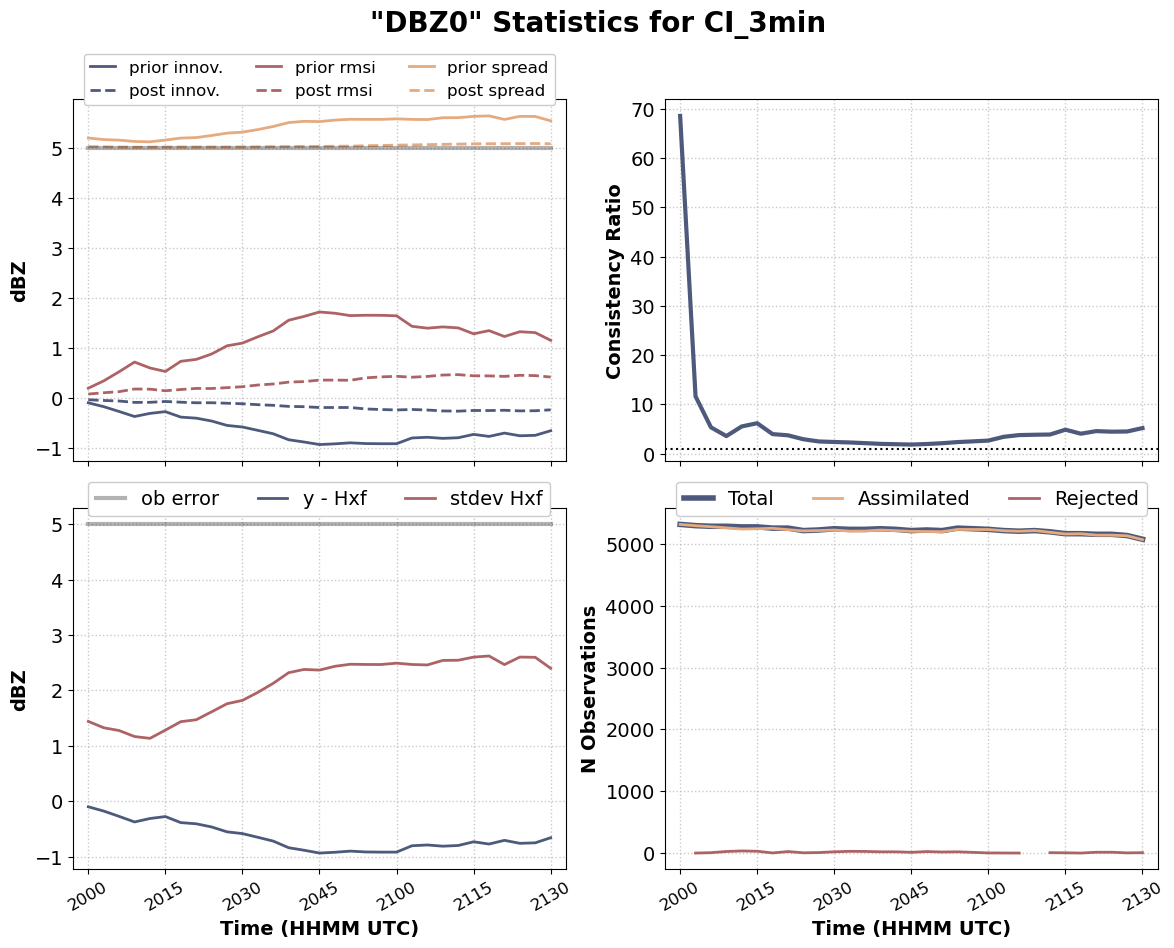

In [93]:
exp = 'CI_3min'

var = 'DBZ0'

plot_obs_stats(exp, var, inlier=False)


In [50]:




def get_counts(exp, var, inlier=False):
    ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)
    with open(os.path.join(exp, os.path.basename(exp)+'.exp'), 'rb') as f: exper = json.load(f)
    start = DT.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')
    times = [(pd.Timestamp(t)-start).seconds/60 for t in ds.time.values]     
    
    
    # obs counts
    outlier = get_var(ds, 'outlier', var, drop_outliers=False)
    Nobs_out= np.count_nonzero(outlier > 3, axis=1).astype(float)
    Nobs_in = np.count_nonzero(outlier < 0.25, axis=1).astype(float)
    Nobs = np.count_nonzero(np.isnan(outlier)==False, axis=1).astype(float)

    if inlier == False: Nobs_in = Nobs_in * 0
        
    Nobs_assim = Nobs - (Nobs_out+Nobs_in)
        
    Nobs_out[np.where(Nobs_out == 0.0)] = np.nan
    Nobs_assim[Nobs_assim == 0.0] = np.nan
    Nobs_in[np.where(Nobs_in == 0.0)] = np.nan


    return times, Nobs, Nobs_assim, Nobs_out, Nobs_in
    


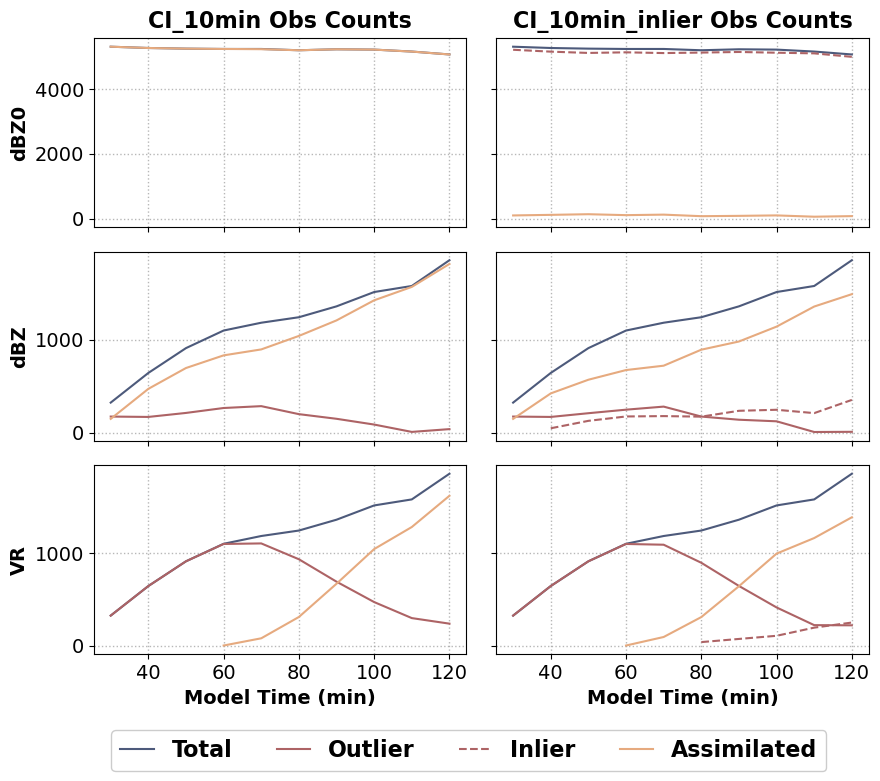

In [65]:
obs = ['DBZ0', 'DBZ', 'VR']


exps = ['CI_3min', 'CI_3min_inlier', 'CI_3min_err_inlier']
exps = ['CI_10min', 'CI_10min_inlier']

if len(exps) == 3:
    fig, axes = plt.subplots(3,3, figsize=(14, 8), sharex=True, sharey='row')

if len(exps) == 2:
    fig, axes = plt.subplots(3,2, figsize=(10, 8), sharex=True, sharey='row')
    
c = cmaps.lipari(np.linspace(.24, .8, 3))

inlier=False
for i, exp in enumerate(exps):
    fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'+exp
    if i == 1:
        inlier=True

    axes[0,i].set_title(os.path.basename(exp)+ ' Obs Counts', fontsize=16, y=1.01, weight='bold')

    for ax, var in zip(axes[:,i], obs):
        

        times, Nobs, Nobs_assim, Nobs_out, Nobs_in = get_counts(fpath, var, inlier=inlier)
        ax.plot(times, Nobs, color=c[0], label='Total')
        ax.plot(times, Nobs_out, color=c[1], label='Outlier')
        ax.plot(times, Nobs_in, color=c[1], ls='--', label='Inlier')
        ax.plot(times, Nobs_assim, color=c[2], label='Assimilated')
        ax.grid(ls=':', alpha=0.7)


plt.subplots_adjust(hspace=0.13, wspace=0.08)
    
axes[0,0].set_ylabel('dBZ0')
axes[1,0].set_ylabel('dBZ')
axes[2,0].set_ylabel('VR')


for ax in axes[2,:].flatten():
    ax.set_xlabel('Model Time (min)')


handles, labels = plt.gca().get_legend_handles_labels()

fig.legend(handles, labels, prop={'size':16, 'weight':'bold'},ncol=4,  handlelength=1.5, loc='lower center', bbox_to_anchor=(0.5, -.05))

In [546]:
exp = 'CI_3min'

ds = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/AllPrior_Post.nc", decode_timedelta=True)

dbz = get_var(ds, "value", 'DBZ0')   
lat = get_var(ds, "y", 'DBZ0') 
lon = get_var(ds, "x", 'DBZ0') 
z = get_var(ds, "z", 'DBZ0')
ds.time.values

array(['2024-05-08T20:00:00.000000000', '2024-05-08T20:03:00.000000000',
       '2024-05-08T20:06:00.000000000', '2024-05-08T20:09:00.000000000',
       '2024-05-08T20:12:00.000000000', '2024-05-08T20:15:00.000000000',
       '2024-05-08T20:18:00.000000000', '2024-05-08T20:21:00.000000000',
       '2024-05-08T20:24:00.000000000', '2024-05-08T20:27:00.000000000',
       '2024-05-08T20:30:00.000000000', '2024-05-08T20:33:00.000000000',
       '2024-05-08T20:36:00.000000000', '2024-05-08T20:39:00.000000000',
       '2024-05-08T20:42:00.000000000', '2024-05-08T20:45:00.000000000',
       '2024-05-08T20:48:00.000000000', '2024-05-08T20:51:00.000000000',
       '2024-05-08T20:54:00.000000000', '2024-05-08T20:57:00.000000000',
       '2024-05-08T21:00:00.000000000', '2024-05-08T21:03:00.000000000',
       '2024-05-08T21:06:00.000000000', '2024-05-08T21:09:00.000000000',
       '2024-05-08T21:12:00.000000000', '2024-05-08T21:15:00.000000000',
       '2024-05-08T21:18:00.000000000', '2024-05-08

In [531]:
ds

<xarray.Dataset> Size: 206MB
Dimensions:       (t: 31, ne: 36, n: 8788)
Coordinates:
  * t             (t) int64 248B 0 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30
  * ne            (ne) int64 288B 0 1 2 3 4 5 6 7 8 ... 28 29 30 31 32 33 34 35
  * n             (n) int64 70kB 0 1 2 3 4 5 6 ... 8782 8783 8784 8785 8786 8787
Data variables: (12/28)
    secs          (t, n) float64 2MB ...
    kind          (t, n) float64 2MB ...
    year          (t, n) float64 2MB ...
    month         (t, n) float64 2MB ...
    day           (t, n) float64 2MB ...
    hour          (t, n) float64 2MB ...
    ...            ...
    DBZ           (t, n) bool 272kB ...
    VR            (t, n) bool 272kB ...
    DBZ0          (t, n) bool 272kB ...
    Hxf_post      (t, n, ne) float64 78MB ...
    Hxfbar_post   (t, n) float64 2MB ...
    outlier_post  (t, n) float64 2MB ...

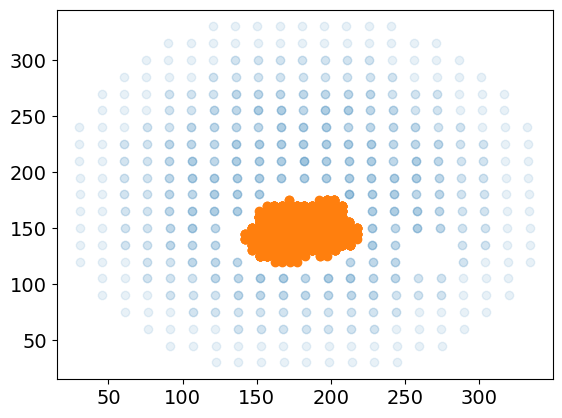

In [557]:
t=15


dbz = get_var(ds, "value", 'DBZ0')   
lat = get_var(ds, "y", 'DBZ0') 
lon = get_var(ds, "x", 'DBZ0') 
z = get_var(ds, "z", 'DBZ0')

mask = (z[t] > 1000 )& (z[t]< 3000)
plt.scatter(lon[t, mask]/1000, lat[t, mask]/1000, alpha=0.1)#dbz[t,:]


dbz = get_var(ds, "value", 'DBZ')   
lat = get_var(ds, "y", 'DBZ') 
lon = get_var(ds, "x", 'DBZ') 
#z = get_var(ds, "z", 'DBZ')
#mask = (z[t] > 1000 )& (z[t]< 3000)
plt.scatter(lon[t]/1000, lat[t]/1000, alpha=1)


In [536]:
np.shape(lat)

(31, 5316)

# Weak Temperature Gradient Approximation

In [3]:
import scipy
import colormaps as cmaps

def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()


def winds_A2C(cm1):

    """
    Creates cell-centered averages from the U/V/W staggered variables using explicit formulas from:
    
    "Brian Sanderson & Gary Brassington (1998): Accuracy in the context of a 
          control volume model, Atmosphere-Ocean, 36:4, 355-384."
    
    Starting from the staggered (face/edge values), the integrated value for the central u-point is
    
     u(i) = (-u(i-3/2) + 13u(i-1/2) + 13u(i+1/2) - u(i+3/2)) / 24
     
    The corresponding edge value for the opposite interpolation is
    
     u(i-1/2) = (-u(i-2) + 7u(i-1) + 7u(i) - u(i+1)) / 12
    
    These formulas are not reversible, but they are significantly less dissipative than 2nd order averaging    
    For the A-grid boundary points, simple 2nd order averages/interpolation will be performed.
    For the velocity on the C-grid boundary points, these values are never changed....
    """

    # staggered grid
    ua = cm1.ua.values[0]
    va = cm1.va.values[0]
    wa = cm1.wa.values[0]
    
    nx = len(cm1.ni)
    ny = len(cm1.nj)
    nz = len(cm1.nk)
    
    u = np.zeros([nz,ny,nx])*np.nan
    v = np.zeros([nz,ny,nx])*np.nan
    w = np.zeros([nz,ny,nx])*np.nan
    
    
    u[:,:,0]      = 0.5*(ua[:,:,0]    + ua[:,:,1])
    u[:,:,nx-1]   = 0.5*(ua[:,:,nx-1] + ua[:,:,nx])
    u[:,:,1:nx-1] = (ua[:,:,0:nx-2]   + 13.0*ua[:,:,1:nx-1] -ua[:,:,3:nx+1] + 13.0*ua[:,:,2:nx] ) / 24.0
    
    
    v[:,0,:]      = 0.5*(va[:,0,:]    + va[:,1,:])
    v[:,ny-1,:]   = 0.5*(va[:,ny-1,:] + va[:,ny,:])
    v[:,1:ny-1,:] = (va[:,0:ny-2,:]   + 13.0*va[:,1:ny-1,:] -va[:,3:ny+1,:] + 13.0*va[:,2:ny,:] ) / 24.0
    
    
    w[0,:,:]      = 0.5*(wa[0,:,:]    + wa[1,:,:])
    w[nz-1,:,:]   = 0.5*(wa[nz-1,:,:] + wa[nz,:,:])
    w[1:nz-1,:,:] = (wa[0:nz-2,:,:]   + 13.0*wa[1:nz-1,:,:] -wa[3:nz+1,:,:] + 13.0*wa[2:nz,:,:] ) / 24.0
    
    return u,v,w

def plot_regression(ax, varx, vary,color='0.4', ls='--', lw=2):
    a1x = np.linspace(np.nanmin(varx)-.02, np.nanmax(varx)+.02)
    slope1, intercept1, rvalue1, pval, stderr = scipy.stats.linregress(varx, vary)
    ax.plot(a1x, slope1*a1x+intercept1, color=color, linestyle=ls,lw=lw)

    ax.text(0.03, .98-.01, r'r$\mathbf{^{2}}$ ='+f'{rvalue1:.4f}',color='0.4', weight='bold',va='top', fontsize=13, transform=ax.transAxes)
    ax.text(0.03, .90-.04, r'slope ='+f'{slope1:.2E}',            color='0.4', weight='bold',va='top', fontsize=13, transform=ax.transAxes)
    

    

In [19]:
#calculating 

members = np.arange(1,37,1)
times = np.arange(0, 37, 1)

for exp in [ 'CI_10min', 'CI_15min']: #'Control', 'CI_5min',
    print("\n"+exp)

    fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/'

    qr   = np.zeros([len(members), len(times)]) #n members, n timesteps
    wres = np.zeros([len(members), len(times)]) #n members, n timesteps
    
    mtime = []
    
    for member in members:
        print(member, end=',')
    
        for i,t in enumerate(times):
        
            cm1 = xr.open_dataset(f'{fpath}member{member:03d}/cm1rst_{t:06d}.nc', decode_timedelta=True)
            mtime.append(int(cm1.time[0]/1e9/60))
            
            # note - this is theta tendencies from the microphysics scheme
            qtten = cm1.qtten.values[0]
            
            # u,v,w = winds_A2C(cm1)

            # calc w
            wa = cm1.wa.values[0]
            nz = len(cm1.nk)
            w = np.zeros_like(qtten)*np.nan
            w[0,:,:]      = 0.5*(wa[0,:,:]    + wa[1,:,:])
            w[nz-1,:,:]   = 0.5*(wa[nz-1,:,:] + wa[nz,:,:])
            w[1:nz-1,:,:] = (wa[0:nz-2,:,:]   + 13.0*wa[1:nz-1,:,:] -wa[3:nz+1,:,:] + 13.0*wa[2:nz,:,:] ) / 24.0
            
            th0 = cm1.theta.values[0,:,:, -10:].mean(axis=(1,2))
            # thp = cm1.theta.values[0] - th0[:, np.newaxis, np.newaxis]# 10 index wide (x-dir, 30 km) strip along edge 
            
            # dx = np.gradient(cm1.xh)
            # dy = np.gradient(cm1.yh)
            dz  = np.gradient(cm1.zh)
            
            dth0dz = np.gradient(th0, axis=0)/dz #K/m
            
            # dthpdx = np.gradient(thp, axis=2)/dx[np.newaxis,   np.newaxis,:]
            # dthpdy = np.gradient(thp, axis=1)/dy[np.newaxis,:, np.newaxis]
            # dthpdz = np.gradient(thp, axis=0)/dz[:,np.newaxis, np.newaxis]
            
            # q_theta = qtten + (u*dthpdx + v*dthpdy + w*dthpdz) + w*dth0dz[:,np.newaxis, np.newaxis]
            
            #W_wtg = q_theta/dth0dz[:, np.newaxis, np.newaxis]
            W_wtg = qtten/dth0dz[:, np.newaxis, np.newaxis]
            W_res = w - W_wtg # residual vertical velocity that is not balanced by heat sources 
            
            wres[member-1, i] = np.mean(np.abs(W_res[findnearest(cm1.zh, 5000)]))
            qr[member-1, i] = cm1.qr[:,:,:,:].mean()
    
            if t == 0:
                cm1_old = xr.open_dataset(f'{fpath}member{member:03d}/cm1rst_{t:06d}.nc', decode_timedelta=True)
                rain[member-1, i]  = np.mean((cm1.rain.values - (cm1_old.rain.values*0))/300)
                
            else:
                cm1_old = xr.open_dataset(f'{fpath}member{member:03d}/cm1rst_{t-1:06d}.nc', decode_timedelta=True)
                rain[member-1, i]  = np.mean((cm1.rain.values - cm1_old.rain.values)/300)
    
            cm1.close()
            cm1_old.close()


    coords = {
            't'    : np.arange(0, len(times)),
            'ne'   : np.arange(0, len(members)),}
    
    data_vars = { 
        'time'                     : (['t'], np.unique(mtime)),
        'wres'                     : (['ne','t'], wres),
        'qr'                       : (['ne','t'], qr)}
    
    myds = xr.Dataset(data_vars, coords)
    myds.to_netcdf(f'{fpath}WTG.nc', format='NETCDF4')



CI_10min
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,
CI_15min
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,

In [ ]:
exp = 'CI_3min_inlier'

for exp in ['CI_15min', 'CI_10min_inlier', 'CI_5min', 'CI_5min_err', 'CI_3min', 'CI_3min_err', 'CI_3min_err_inlier']:
    print(exp)

    with open(os.path.join('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'+exp ,os.path.basename(exp)+'.exp'), 'rb') as f: exper = json.load(f)
    
    members = np.arange(1,exper['ne']+1,1)
    times = np.arange(0, len(glob.glob(exper['fcst_members'][0]+'/cm1rst*')), 1)
    
    fpath = exper['base_path']
    
    qr   = np.zeros([len(members), len(times)]) #n members, n timesteps
    wres = np.zeros([len(members), len(times)]) #n members, n timesteps
    
    mtime = []
    
    for member in members:
        print(member, end=',')
    
        # replace posteriors with the priors 
        mem_rst   = sorted(glob.glob(os.path.join(fpath, f'member{member:03d}','cm1rst*.nc')))
        mem_prior = sorted(glob.glob(os.path.join(fpath, f'member{member:03d}','cm1_prior*.nc')))
    
        mem_prior_num = [int(re.findall(r"\d+",os.path.basename(f))[-1]) for f in mem_prior]
        for i,f in enumerate(mem_rst):
            if int(re.findall(r"\d+",os.path.basename(f))[-1]) in mem_prior_num:
                mem_rst[i] = mem_rst[i].replace('rst', '_prior')
        
        for i,f in enumerate(mem_rst):
            
            cm1 = xr.open_dataset(f, decode_timedelta=True)
            mtime.append(int(cm1.time[0]/1e9/60))
            
            # note - this is theta tendencies from the microphysics scheme
            qtten = cm1.qtten.values[0]
            
            # calc w
            wa = cm1.wa.values[0]
            nz = len(cm1.nk)
            w = np.zeros_like(qtten)*np.nan
            w[0,:,:]      = 0.5*(wa[0,:,:]    + wa[1,:,:])
            w[nz-1,:,:]   = 0.5*(wa[nz-1,:,:] + wa[nz,:,:])
            w[1:nz-1,:,:] = (wa[0:nz-2,:,:]   + 13.0*wa[1:nz-1,:,:] -wa[3:nz+1,:,:] + 13.0*wa[2:nz,:,:] ) / 24.0
            
            th0 = cm1.theta.values[0,:,:, -10:].mean(axis=(1,2))
            dz  = np.gradient(cm1.zh)
            
            dth0dz = np.gradient(th0, axis=0)/dz #K/m
    
            W_wtg = qtten/dth0dz[:, np.newaxis, np.newaxis]
            W_res = w - W_wtg # residual vertical velocity that is not balanced by heat sources 
            
            wres[member-1, i] = np.mean(np.abs(W_res[findnearest(cm1.zh, 5000)]))
            qr[member-1, i] = cm1.qr[:,:,:,:].mean()
    
            cm1.close()
    
    coords = {
            't'    : np.arange(0, len(times)),
            'ne'   : np.arange(0, len(members)),}
    
    data_vars = { 
        'time'                     : (['t'], np.unique(mtime)),
        'wres'                     : (['ne','t'], wres),
        'qr'                       : (['ne','t'], qr)}
    
    myds = xr.Dataset(data_vars, coords)
    myds.to_netcdf(f'{fpath}/WTG_new.nc', format='NETCDF4')


CI_15min
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,CI_10min_inlier
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,CI_5min
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,CI_5min_err
1,

In [54]:
myds.to_netcdf(f'{fpath}/WTG_test.nc', format='NETCDF4')

In [37]:
fpath+expmembe
myds.to_netcdf(f'{fpath+exp}/WTG_test.nc', format='NETCDF4')

Text(0.5, 1.06, 'Control Run (no DA) 30-180 Minutes')

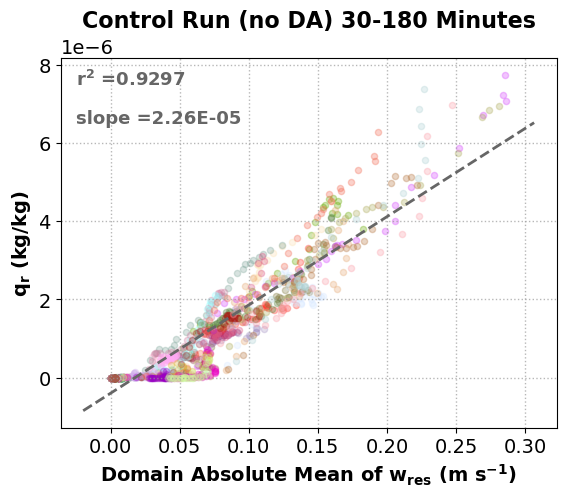

In [73]:
control = xr.open_dataset(f'{fpath}Control/WTG.nc')

ti      = findnearest(control.time, 0)
tti     = findnearest(control.time, 180)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][:,ti:].values.ravel(), control[vary][:,ti:].values.ravel())

fig,ax=plt.subplots()

members = np.arange(0, 36, 1)

colors=cmaps.cet_g_bw_minc_minl(np.linspace(0,1,256))
colors=cmaps.cet_g_bw_minc_minl(np.linspace(0,1,256))
#colors=cmaps.cet_g_category10(np.linspace(0,1,256))


for m in members:
    ax.scatter(control.wres[m,ti:tti+1], control.qr[m,ti:tti+1],  s=20, alpha=.3, color=colors[m+70])

plot_regression(ax, control.wres[:,ti:tti+1].values.ravel(), control.qr[:,ti:tti+1].values.ravel())


ax.set_ylabel(r'q$\mathbf{_r}$ (kg/kg)');
ax.set_xlabel(r'Domain Absolute Mean of w$\mathbf{_{res}}$ (m s$\mathbf{^{-1}}$)');

ax.grid(ls=':', alpha=0.7)

ax.set_title('Control Run (no DA) 30-180 Minutes', y=1.06, fontsize=16, weight='bold')

In [ ]:
# weak tmperature gradient approx tests
# import scipy 

members = np.arange(0, 36, 1)

fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'
exps = ['CI_15min','CI_10min','CI_5min', 'CI_3min'] #'CI_10min_inlier',
exps = ['CI_3min', 'CI_3min_inlier', 'CI_3min_err_inlier','CI_3min_err']
#exps = ['CI_10min','CI_5min', 'CI_5min_err','CI_3min', 'CI_3min_err']

exps = ['CI_10min', 'CI_3min_inlier']

colors = cmaps.lipari(np.linspace(.28, .85, 2+len(exps)))

vary = 'qr'



fig,ax = plt.subplots(figsize=(10, 6))

control = xr.open_dataset(f'{fpath}Control/WTG.nc')
ti      = findnearest(control.time, 30)
tti     = findnearest(control.time, 120)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][:,ti:].values.ravel(), control[vary][:,ti:].values.ravel())
control_rain = control[vary].values

ax.plot(control.time, control.wres.mean(axis=0), color='k', label='Control', ls='--')


label_flag = True

ls = ['-', '-', '--', '-', '--']

ls = ['-', '-', '-', '-', '-']

for i,exp in enumerate(exps): 
    wtd = xr.open_dataset(f'{fpath}{exp}/WTG.nc')

    wres = wtd['wres'].values
    rain = wtd[vary].values

    
    
    if np.any(np.gradient(wtd.time) < np.mean(np.gradient(control.time))):

        ti_i = findnearest(wtd.time, 30)
        rain_interp = []
        for m in members:
            rain_interp.append(np.interp( wtd.time.values, control.time.values, control.qr.values[m]))


        tii      = findnearest(wtd.time, 30)
        ttii     = findnearest(wtd.time, 120)

        wtd_adjusted = (wres- (1/slope)*(rain - rain_interp)).mean(axis=0)
        ax.plot(wtd.time[tii:], wtd_adjusted[tii:], color=colors[i], lw=3,ls=ls[i], label=exp)
        ci = int(re.findall(r'\d+\.?\d*', exp)[0])

        #scat = ax.scatter(np.arange(30, 121, ci),  wtd_adjusted[tii:ttii+1], color=colors[i], marker='s', s=15, edgecolor='k', zorder=20)
        
    else:

        wtd_adjusted = (wres- (1/slope)*(rain - control_rain)).mean(axis=0)
        
        ax.plot(wtd.time[ti:], wtd_adjusted[ti:], color=colors[i], lw=3, ls=ls[i],label=exp)

        ci = int(re.findall(r'\d+\.?\d*', exp)[0])

        #scat =ax.scatter(np.arange(30, 121, ci),  wtd_adjusted[ti:tti+1][::int(ci/5)], color=colors[i], marker='s', s=15, edgecolor='k', zorder=20)''

    wtd = xr.open_dataset(f'{fpath}{exp}/WTG_test.nc')

    wres = wtd['wres'].values
    rain = wtd[vary].values

    
    
    if np.any(np.gradient(wtd.time) < np.mean(np.gradient(control.time))):

        ti_i = findnearest(wtd.time, 30)
        rain_interp = []
        for m in members:
            rain_interp.append(np.interp( wtd.time.values, control.time.values, control.qr.values[m]))


        tii      = findnearest(wtd.time, 30)
        ttii     = findnearest(wtd.time, 120)

        wtd_adjusted = (wres- (1/slope)*(rain - rain_interp)).mean(axis=0)
        ax.plot(wtd.time[tii:], wtd_adjusted[tii:], color=colors[i+2], lw=3,ls='--', label=exp+'priors')
        ci = int(re.findall(r'\d+\.?\d*', exp)[0])

        #scat = ax.scatter(np.arange(30, 121, ci),  wtd_adjusted[tii:ttii+1], color=colors[i], marker='s', s=15, edgecolor='k', zorder=20)
        
    else:

        wtd_adjusted = (wres- (1/slope)*(rain - control_rain)).mean(axis=0)
        
        ax.plot(wtd.time[ti:], wtd_adjusted[ti:], color=colors[i+1], lw=3, ls='--',label=exp+'priors')

        ci = int(re.findall(r'\d+\.?\d*', exp)[0])

        #scat =ax.scatter(np.arange(30, 121, ci),  wtd_adjusted[ti:tti+1][::int(ci/5)], color=colors[i], marker='s', s=15, edgecolor='k', zorder=20)

        

    ax.plot(wtd.time[:ti+1], wtd['wres'][:,:ti+1].mean(axis=0), color='k', alpha=0.3)
    ax.scatter(wtd.time[ti], wtd['wres'][:,ti].mean(axis=0),color='k', marker='s', s=15, edgecolor='k', zorder=20)

ax.set_title(r"Corrected Mean Absolute of W$\mathbf{_{WTG}}$ Residual", weight='bold', y=1.02)
ax.set_xlabel('Model Time (minutes)')
ax.set_ylabel(r'm s$\mathbf{^{-1}}$');

ax.axvspan(30, 120, color='0.6', alpha=0.1, label='Active DA')

ax.grid(ls=':', alpha=0.7)

handles, labels =ax.get_legend_handles_labels()
n = len(labels)

# handles.append(scat)
# labels.append('Time of DA')

scatterpoints=np.clip(len(exps), 1, 3)


leg=ax.legend(handles, labels, fontsize=14, scatterpoints=scatterpoints, markerscale=1.5, loc=2)
#leg.legend_handles[n].set_facecolors(colors)


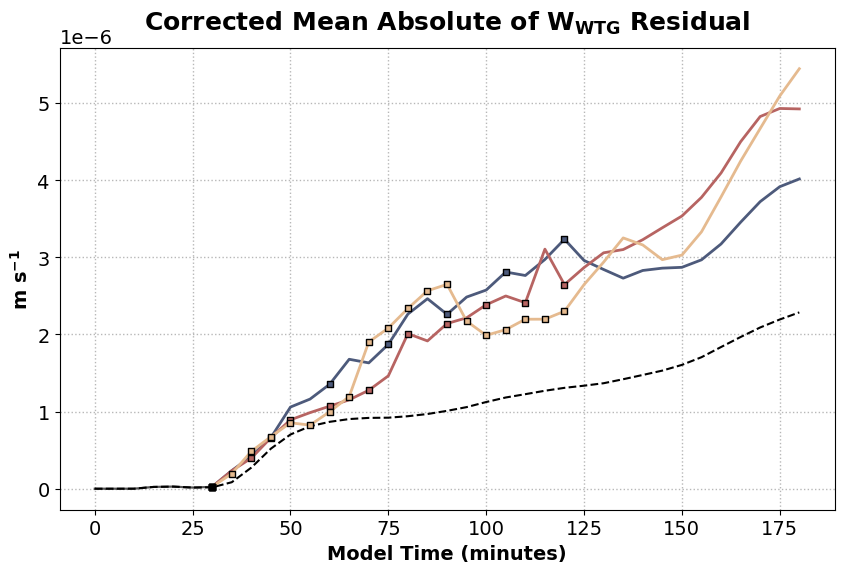

In [31]:
# weak tmperature gradient approx tests
# import scipy 



fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'
exps = ['CI_15min','CI_10min','CI_5min']
labels = [ '15 min CI', '10 min CI', '5 min CI']

colors = cmaps.lipari(np.linspace(.24, .85, len(exps)))

#vary = 'rain_accum_5min_mean'
vary = 'qr'



fig,ax = plt.subplots(figsize=(10, 6))

control = xr.open_dataset(f'{fpath}Control/WTD.nc')
ti      = findnearest(control.time, 30)
tti     = findnearest(control.time, 120)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][:,ti:].values.ravel(), control[vary][:,ti:].values.ravel())
control_rain = control[vary].values

ax.plot(control.time, control.qr.mean(axis=0), color='k', label='Control', ls='--')

for i,exp in enumerate(exps): 
    wtd = xr.open_dataset(f'{fpath}{exp}/WTD.nc')

    wres = wtd['wres'].values
    rain = wtd[vary].values.mean(axis=0)
    wtd_adjusted = (wres).mean(axis=0)# - (1/slope)*(rain - control_rain)).mean(axis=0)

    #ax.plot(wtd.time[ti:], wtd_adjusted[ti:], color=colors[i], lw=2, label=labels[i], alpha=0.5)

    wtd_adjusted = (wres- (1/slope)*(rain - control_rain)).mean(axis=0)

    ax.plot(wtd.time[ti:], rain[ti:], color=colors[i], lw=2, label=labels[i])
    
    ax.scatter(np.arange(30, 121, 5*(len(exps)-i)),  rain[ti:tti+1][::(3-i)], color=colors[i], marker='s', s=15, edgecolor='k', zorder=20, label=f'Time of DA')

    ax.plot(wtd.time[:ti+1], wtd['qr'][:,:ti+1].mean(axis=0), color='k', alpha=0.3)
    ax.scatter(wtd.time[ti], wtd['qr'][:,ti].mean(axis=0),color='k', marker='s', s=15, edgecolor='k', zorder=20)

ax.set_title(r"Corrected Mean Absolute of W$\mathbf{_{WTG}}$ Residual", weight='bold', y=1.02)
ax.set_xlabel('Model Time (minutes)')
ax.set_ylabel(r'm s$\mathbf{^{-1}}$');

ax.grid(ls=':', alpha=0.7)

# handles, labels =ax.get_legend_handles_labels()
# new_handles,new_labels = [handles[0],handles[1],handles[3],handles[5], (handles[2])], [labels[0], labels[1],labels[3], labels[5], labels[2]]
# leg=ax.legend(new_handles, new_labels, fontsize=14, scatterpoints=3, markerscale=1.5)
# leg.legend_handles[4].set_facecolors(colors)


In [170]:
for c in col1:
    print(c)

[1.         1.         0.89803922 1.        ]
[0.9812995  0.99298731 0.79518647 1.        ]
[0.94232987 0.97771626 0.70620531 1.        ]
[0.86851211 0.94818916 0.65207228 1.        ]
[0.76842753 0.90552864 0.59981546 1.        ]
[0.65642445 0.85711649 0.54814302 1.        ]
[0.52601307 0.80052288 0.49647059 1.        ]
[0.39277201 0.7382699  0.43489427 1.        ]
[0.25743945 0.67183391 0.36599769 1.        ]
[0.18246828 0.57642445 0.30193003 1.        ]
[array([0.18246828, 0.59784698, 0.34443676, 1.        ]), array([0.256609  , 0.68327566, 0.46486736, 1.        ]), array([0.3476509 , 0.7324875 , 0.57805459, 1.        ]), array([0.45333333, 0.78379085, 0.68183007, 1.        ]), array([0.57882353, 0.83792388, 0.77287197, 1.        ]), array([0.70431373, 0.88796617, 0.84755094, 1.        ]), array([0.81460977, 0.93074971, 0.91306421, 1.        ]), array([0.87612457, 0.95289504, 0.95981546, 1.        ]), array([0.92655133, 0.97187236, 0.98280661, 1.        ]), array([0.96862745, 0.98823

In [5]:
import cmocean

In [6]:
import cmasher as cmr

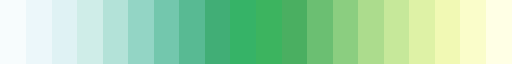

In [246]:
col1 = list(plt.cm.YlGn(np.linspace(0,.68, 10)))
col2 = list(plt.cm.BuGn(np.linspace(0,.7, 10))[::-1])
col1.extend(col2)
clist = [to_rgb(c) for c in col1[::-1]]
i1,i2 = 9,11
clist[i1:i2] = np.array(clist[i1:i2])*1.18
cmap = LinearSegmentedColormap.from_list("CR", clist, 20)
#return cmap

#cmap = LinearSegmentedColormap.from_list("CR", clist, 20)
cmap

# combining Priors, making Posteriors

RETURNING 2D FIELDS
[   0 2000 4000 6000]
RETURNING 2D FIELDS
[   0 2000 4000 6000]


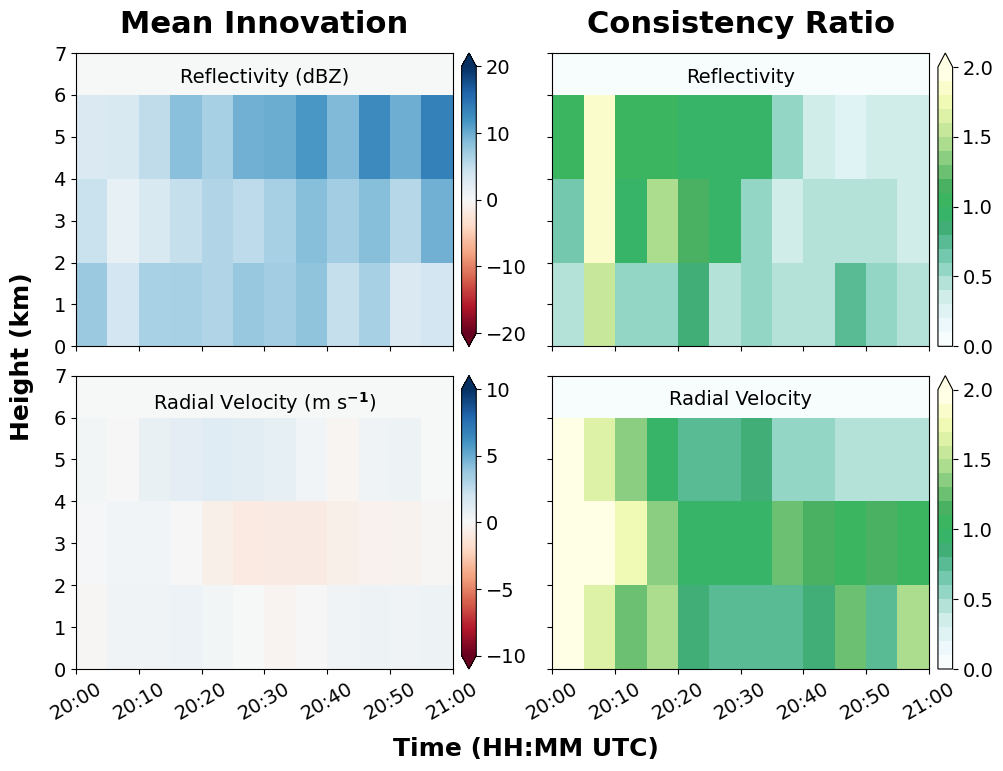

In [102]:
fig, axes = plt.subplots(2,2, figsize=(12,8), sharey=True, sharex=True)

vals = [20, 10]
fs = 14
cmap = CR_cmap()

for ii,var in enumerate(['REF', 'VR']): 
    TZ, CR, IN, SPRD, RMSI = get_stats_timeseries(experiment_location, only_pos_dbz=True, variable=var, full_field=True, dz=2000)
    t, z = list(TZ[0]), list(TZ[1]/1000)
    z.append(z[-1]+z[1]-z[0])
    t.append(t[-1]+(t[1]-t[0]))
    im1 = axes[ii,0].pcolormesh(t,z, IN, vmin=-1*vals[ii], vmax=vals[ii], cmap='RdBu')
    im2 = axes[ii,1].pcolormesh(t,z, CR, vmin=0, vmax=2, cmap=cmap)

    if ii ==1:format_time_ticks(axes[ii,0],t[:-1]);format_time_ticks(axes[ii,1],t[:-1])

    if ii==0: 
        axes[ii,0].text(0.5, .95, 'Reflectivity (dBZ)', ha='center', va='top', transform=axes[ii,0].transAxes, fontsize=fs )
        axes[ii,1].text(0.5, .95, 'Reflectivity',       ha='center', va='top', transform=axes[ii,1].transAxes, fontsize=fs )

    if ii==1: 
        axes[ii,0].text(0.5, .95, r'Radial Velocity (m s$\mathbf{^{-1}}$)', ha='center', va='top', transform=axes[ii,0].transAxes, fontsize=fs )
        axes[ii,1].text(0.5, .95, 'Radial Velocity',                        ha='center', va='top', transform=axes[ii,1].transAxes, fontsize=fs )

    plt.colorbar(im1, ax =axes[ii,0], pad=.02, extend='both')
    plt.colorbar(im2, ax =axes[ii,1], pad=.02, extend='max') 

axes[0,0].set_ylim(0,7)

plt.subplots_adjust(hspace=.1, wspace=0.05)

axes[0,0].set_title('Mean Innovation',   weight='bold',fontsize=22, y=1.04)
axes[0,1].set_title('Consistency Ratio', weight='bold',fontsize=22, y=1.04)

fig.text(0.5, 0.01, 'Time (HH:MM UTC)', ha='center', va='center', weight='bold', fontsize=18);
fig.text(0.07,0.5, 'Height (km)', weight='bold', va='center', fontsize=18, rotation='vertical');

In [144]:
13*9798

127374

In [4]:
##### SAVING PRIORS

# prior
exp = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_inlier'

file_version = 'Prior' 
dirname = os.path.join(exp,file_version+'*.nc')
file_list = sorted(glob.glob(dirname),key=os.path.getmtime)

num2obs = {11: ["VR"], 12:["DBZ"], 13:['DBZ0'], 14:['DBZ0_W']}
obs2num  = {'VR':11, 'DBZ':12, 'DBZ0':13, 'DBZ0_W':14}

with open(f'{exp}/{os.path.basename(exp)}.exp', 'rb') as f: exper = json.load(f)
obs = exper['DA_PARAMS']['obs_included']
obnum = [obs2num[ob] for ob in obs]

ensN = exper['ne']
t    = len(file_list)
n = np.max([len(xr.open_dataset(file).ob_num) for file in file_list])
times = [datetime.strptime(os.path.basename(file).replace(file_version, ''), '_%Y-%m-%d_%H:%M:%S.nc') for file in file_list]


# step one - make the skeleton of dataset
coords = { 't': np.arange(0, t),'ne': np.arange(0,ensN),'n':  np.arange(0, n)}
myds = xr.Dataset( coords)
#print(myds.keys())


# fill with nan variables of proper size
f = xr.open_dataset(file_list[0])
for v in list(f.keys()):
    if v not in ['type', 'dates']:
        if len(np.shape(f[v])) == 1:
            myds[v] = (('t', 'n'), np.zeros([t, n])*np.nan)
        if len(np.shape(f[v])) == 2:
            myds[v] = (('t', 'n', 'ne'), np.zeros([t, n, ensN])*np.nan)
f.close()
            
# fill nan variables with actual data
for fi, file in enumerate(file_list):
    f = xr.open_dataset(file)
    fn = len(f.ob_num)
    for v in list(myds.keys()):
        myds[v][fi, :fn] = f[v].values
    f.close()

# add time var
myds['time'] =  (('t'), times) 

# add masks for different variables

fix_kinds = myds.kind.values
fix_kinds[np.isnan(fix_kinds)] = -999
myds['kind'] = (('t', 'n'), fix_kinds)
for ob in obs:
    myds[ob] = (('t', 'n'), myds['kind'].values == obs2num[ob])


##### now add in the posterior values!!
myds['Hxf_post']= (('t', 'n', 'ne'), np.zeros([t, n, ensN])*np.nan)
myds['Hxfbar_post']= (('t', 'n'), np.zeros([t, n])*np.nan)
myds['outlier_post']= (('t', 'n'), np.zeros([t, n])*np.nan)

file_version='Posterior'
dirname = os.path.join(exp,file_version+'*.nc')
file_list = sorted(glob.glob(dirname),key=os.path.getmtime)
for fi, file in enumerate(file_list):
    f = xr.open_dataset(file)
    fn = len(f.ob_num)
    #for v in list(myds.keys()):
    myds['Hxf_post'][fi, :fn] = f['Hxf'].values
    myds['Hxfbar_post'][fi, :fn] = f['Hxfbar'].values
    myds['outlier_post'][fi, :fn] = f['outlier'].values
    f.close()

savename = os.path.join(os.path.dirname(file_list[0]), f'AllPrior_Post.nc')
myds.to_netcdf(savename, format='NETCDF4')

In [95]:
exp = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_0'
ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)
var = 'DBZ'

#dates,dates_n, IN, CR, SPRD, RMSI = get_stats_times(var, exp)



In [318]:
dates,dates_n, IN, CR, SPRD, RMSI = get_stats_times(var, exp)
print(var, exp)

DBZ0_W /work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w


/tmp/ipykernel_2027532/2346624567.py:35: RuntimeWarning: Degrees of freedom <= 0 for slice.
  Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical


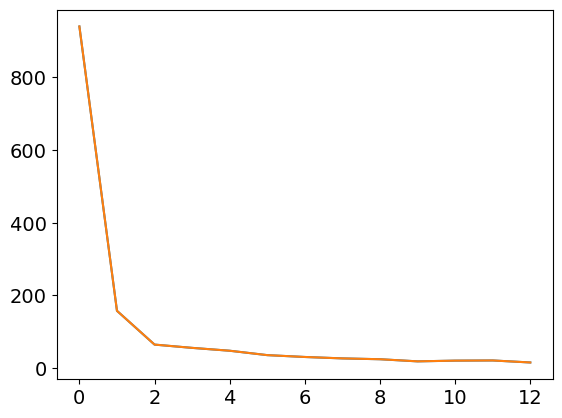

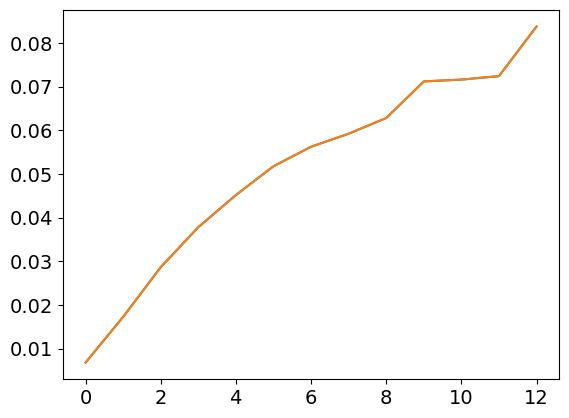

In [156]:
plt.figure()
plt.plot(crt)
plt.plot(CR)

plt.figure()
plt.plot(RMSI)
plt.plot(RMSI_n)

In [157]:
new_inno = [None]*(len(times)*2)
new_inno[::2] = inno
new_inno[1::2] = inno_post

new_time = [None]*(len(times)*2)
new_time[::2] =times
new_time[1::2] = times

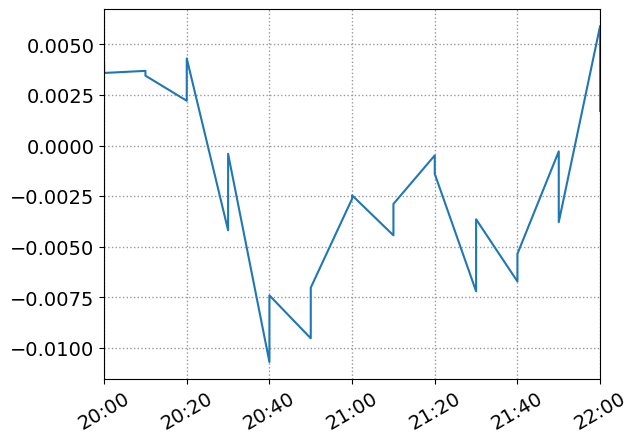

In [168]:
fig,ax = plt.subplots()
ax.plot(new_time, new_inno)
ax.grid()
format_time_ticks(ax,new_time, approx_number_of_ticks=6)

In [26]:


hxf_dbz = get_var(ds, 'Hxf', 'DBZ')
hxf_vr = get_var(ds, 'Hxf', 'VR')

hxf_dbz_post = get_var(ds, 'Hxf_post', 'DBZ')
hxf_vr_post = get_var(ds, 'Hxf_post', 'VR')

outliers = get_var(ds, 'outlier', 'DBZ')
hxf_dbz[outliers > 3] = np.nan

In [97]:
err = get_var(ds, 'error', 'DBZ')
err = err[np.isnan(err)==False]
np.unique(err)

array([49.])

array([49.])

In [24]:
np.shape(hxf_dbz)

hxf_dbz[outliers > 3] = np.nan

(13, 2426, 36)

In [25]:
np.shape(outliers)

(13, 2426)

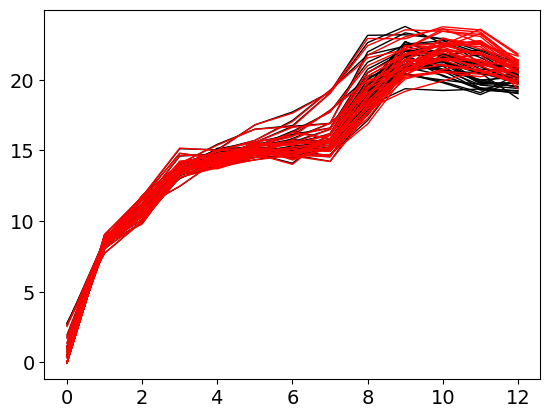

In [28]:

hxf_dbz = get_var(ds, 'Hxf', 'DBZ')
plt.plot(np.nanmean(hxf_dbz , axis=1), lw=1, color='k');

hxf_dbz[outliers > 3] = np.nan
plt.plot(np.nanmean(hxf_dbz , axis=1), lw=1, color='r');
#plt.plot(np.nanmean(hxf_dbz_post[outliers<=3] , axis=1), lw=1, color='r');

In [227]:
pos1[0]

Timestamp('2024-05-08 20:03:00')

In [266]:
def draw_plot(ax,data, pos,edge_color, fill_color):
  
    bp = ax.boxplot(data, positions= pos, widths=0.3, patch_artist=True, sym='d')
    for element in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
        plt.setp(bp[element], color=edge_color)
    for patch in bp['boxes']:
        patch.set(facecolor=fill_color)
    plt.setp(bp['fliers'], markersize=3.0)
    plt.setp(bp['fliers'], alpha=0.5)

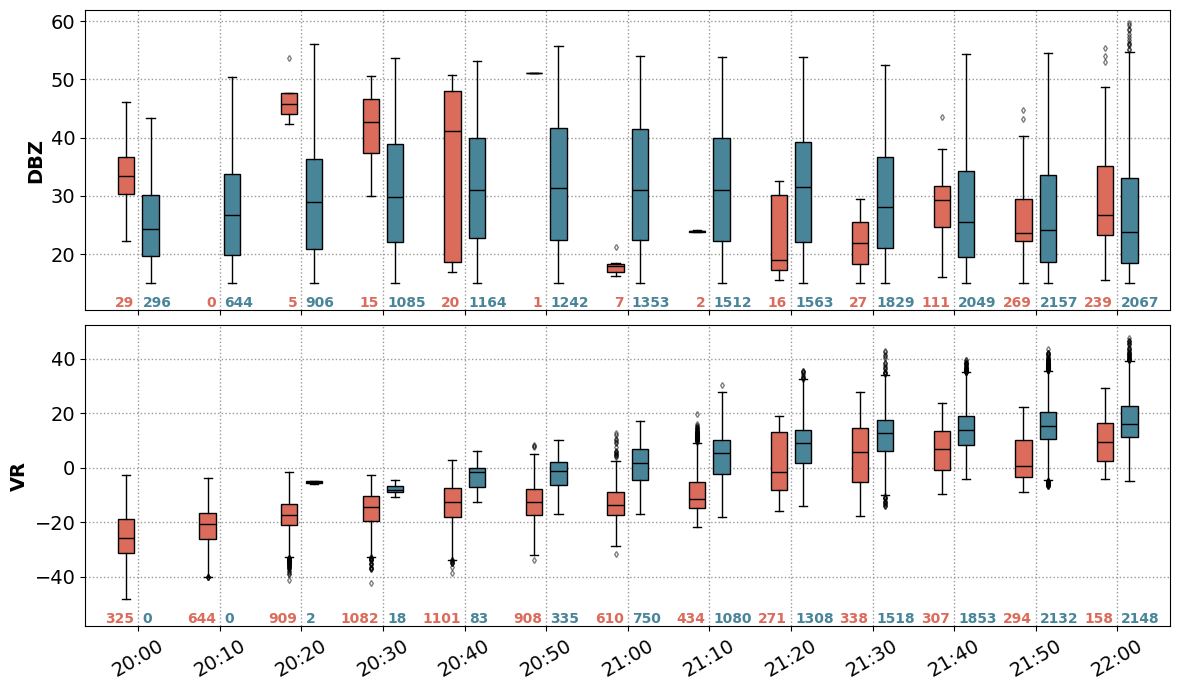

In [312]:
fig, axes = plt.subplots(2,1, figsize=(14, 8),sharex=True)

for ax, var in zip(axes, [ 'DBZ', 'VR']):

    keep_vals = []
    drop_vals = []
    
    for t in np.arange(13):
        sub = get_ds(ds, var, t)
     
        keep_vals.append(sub.value.values[sub.outlier <= 3])
        drop_vals.append(sub.value.values[sub.outlier > 3])
        
    num_keep = [len(v) for v in keep_vals]
    num_drop = [len(v) for v in drop_vals]

   

    offset=0.15
    pos1, pos2 = np.arange(len(keep_vals))+offset,np.arange(len(keep_vals))-offset
    
    draw_plot(ax,keep_vals, pos1,  'k', '#498599')
    draw_plot(ax, drop_vals, pos2, 'k', '#db6b5a')
    
    y1, y2 = (ax.get_ylim())
    yoff = (y2-y1)*.05
    ax.set_ylim(y1-yoff, y2)
    
    y1, y2 = (ax.get_ylim())
    yoff = (y2-y1)*.01
    y = y1+yoff
    for x in np.arange(len(keep_vals)):
        ax.text(x-.05,y, num_drop[x], ha='right',weight='bold', color='#db6b5a')
        ax.text(x+.05,y, num_keep[x], ha='left', weight='bold', color='#498599')
    
    ax.set_xticks(np.arange(len(keep_vals)), [t.strftime('%H:%M') for t in times], rotation=30);
    ax.grid()

    ax.set_ylabel(var)

plt.subplots_adjust(hspace=0.05)


In [9]:



# figure out dimensions for arrays
ensN = exper['ne']
t    = len(file_list)


In [ ]:
# step one, make the 

In [107]:

values    = np.zeros([t,n])*np.nan
outlier   = np.zeros([t,n])*np.nan
var_stdev = np.zeros([t,n])*np.nan



Hxf    = np.zeros([t,n,ensN])*np.nan


In [111]:
np.shape(outlierL[0])


(5966,)

In [64]:
np.shape(kindL[0, kindL[0] == 11])

TypeError: list indices must be integers or slices, not tuple

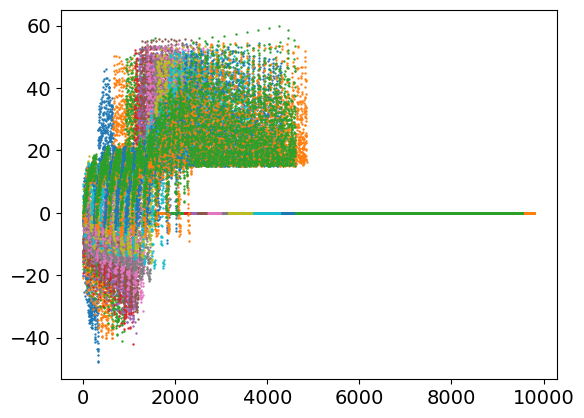

In [61]:
for i in range(allf):
    plt.scatter(range(len(values[i])), values[i], s=0.5)

In [42]:
values = np.zeros([len(file_list), size])*np.nan

In [47]:
for i in range(allf):
    valsize = len(valueL[i])
    values[i, :valsize] = valueL[i]

In [ ]:
size = np.max([np.shape(valueL[i]) for i in range(allf)])

In [45]:

size = np.max([np.shape(valueL[i]) for i in range(allf)])

In [26]:
dirname = os.path.join(exps[1],_prior_files)
#plotfilename='DBZ_CR'
#noshow=True

bin_delta=1

file_list = glob.glob(dirname)
file_list = sorted(file_list,key=os.path.getmtime)

full=[]
fop = []
variable='REF0'

    #full.append( value[index] - Hxf[index,:] ) #hxfbar is the mean model values

for n, file in enumerate(file_list):

        f = ncdf.Dataset(file)

        if n % bin_delta == 0:
            HxfL,valueL,depL,errorL,secsL,zL,kindL = [],[],[],[],[],[],[]

        valueL.append(f.variables["value"][:])
        HxfL.append(f.variables["Hxf"][:]) #hxf is the model value at the location of that ob
        zL.append(f.variables["z"][:] - radar_hgt)
        depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] ) #hxfbar is the mean model values at that location
        secsL.append(f.variables["secs"][:])
        errorL.append(np.sqrt(f.variables["error"][:])) # error is the standard deviation
        kindL.append(ncdf.chartostring(f.variables["type"][:]))

        if n % bin_delta == bin_delta-1:
            Hxf   = np.concatenate(HxfL, axis=0)
            value = np.concatenate(valueL, axis=0)
            z     = np.concatenate(zL, axis=0)
            dep   = np.concatenate(depL, axis=0)
            secs  = np.concatenate(secsL, axis=0)
            error = np.concatenate(errorL, axis=0)
            kind  = np.concatenate(kindL, axis=0)
            #datebins.append(DT.datetime.utcfromtimestamp(secs.mean()))


            index_kind  = getIndexVariable(kind,variable)

            temp = (dep[index_kind][:])# - Hxf[index_kind,:])
            temp2 = Hxf[index_kind,:]
            if n == 0:
                full = temp.copy()
                fop = temp2.copy()
            else:
                full = np.concat([full, temp], axis=0)
                fop = np.concat([fop, temp2], axis=0)
            

In [351]:
exp = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w'
ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)

var='DBZ0_W'

full = (get_var(ds,'value', var)[:,:,np.newaxis]-get_var(ds,'Hxf', var)).flatten()
full = full[np.isnan(full)==False]

In [ ]:
for i in r

In [354]:
bins

array([-38.19175564, -38.09175564, -37.99175564, -37.89175564,
       -37.79175564, -37.69175564, -37.59175564, -37.49175564,
       -37.39175564, -37.29175564, -37.19175564, -37.09175564,
       -36.99175564, -36.89175564, -36.79175564, -36.69175564,
       -36.59175564, -36.49175564, -36.39175564, -36.29175564,
       -36.19175564, -36.09175564, -35.99175564, -35.89175564,
       -35.79175564, -35.69175564, -35.59175564, -35.49175564,
       -35.39175564, -35.29175564, -35.19175564, -35.09175564,
       -34.99175564, -34.89175564, -34.79175564, -34.69175564,
       -34.59175564, -34.49175564, -34.39175564, -34.29175564,
       -34.19175564, -34.09175564, -33.99175564, -33.89175564,
       -33.79175564, -33.69175564, -33.59175564, -33.49175564,
       -33.39175564, -33.29175564, -33.19175564, -33.09175564,
       -32.99175564, -32.89175564, -32.79175564, -32.69175564,
       -32.59175564, -32.49175564, -32.39175564, -32.29175564,
       -32.19175564, -32.09175564, -31.99175564, -31.89

[     1      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      1      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      1      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      1      0
      

(-5.0, 0.1)

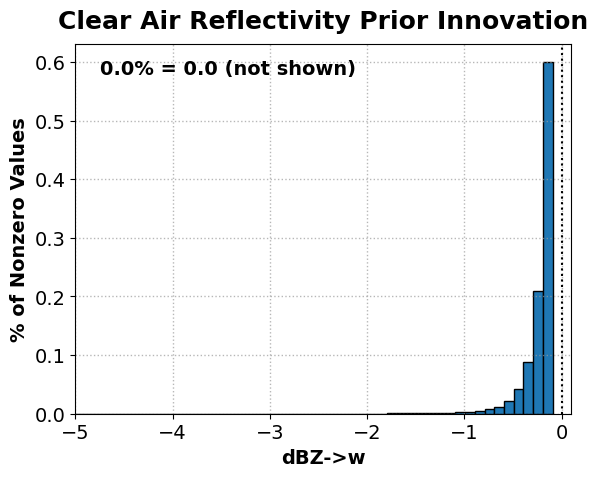

In [353]:
eqzero = 100*list(full.flatten()).count(0.0)/len(full.flatten())

width = .1
bins = np.arange(np.min(full), 0, width)
counts, bin_edges  = np.histogram(full.flatten(), bins=bins)
#ncounts, nbin_edges  = np.histogram(full.flatten(), bins=bins)

print(counts)

print(sum(counts))
#print(sum(ncounts))

bin_c= (bin_edges[:-1] + bin_edges[1:]) / 2
#nbin_c = (nbin_edges[:-1] + nbin_edges[1:]) / 2

fig=plt.figure()
plt.title('Clear Air Reflectivity Prior Innovation', weight='bold', y=1.02)
plt.bar(bin_c, counts/sum(counts), width=width, edgecolor='k')

plt.text(0.05, .96, f"{eqzero:.1f}% = 0.0 (not shown)",va='top', fontsize=14, weight='bold', transform=plt.gca().transAxes)

plt.xlabel('dBZ->w')
plt.ylabel('% of Nonzero Values')
plt.axvline(0, color='k', ls=':')
plt.grid(ls=":", alpha=0.7)

plt.xlim(-5, .1)

/tmp/ipykernel_1466515/2940125403.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs1=axC.contourf(datebins, zbins/1000., CR_TZ, clevels, cmap=cm.get_cmap('YlOrRd'))


Text(0.5, 0, 'Time (UTC)')

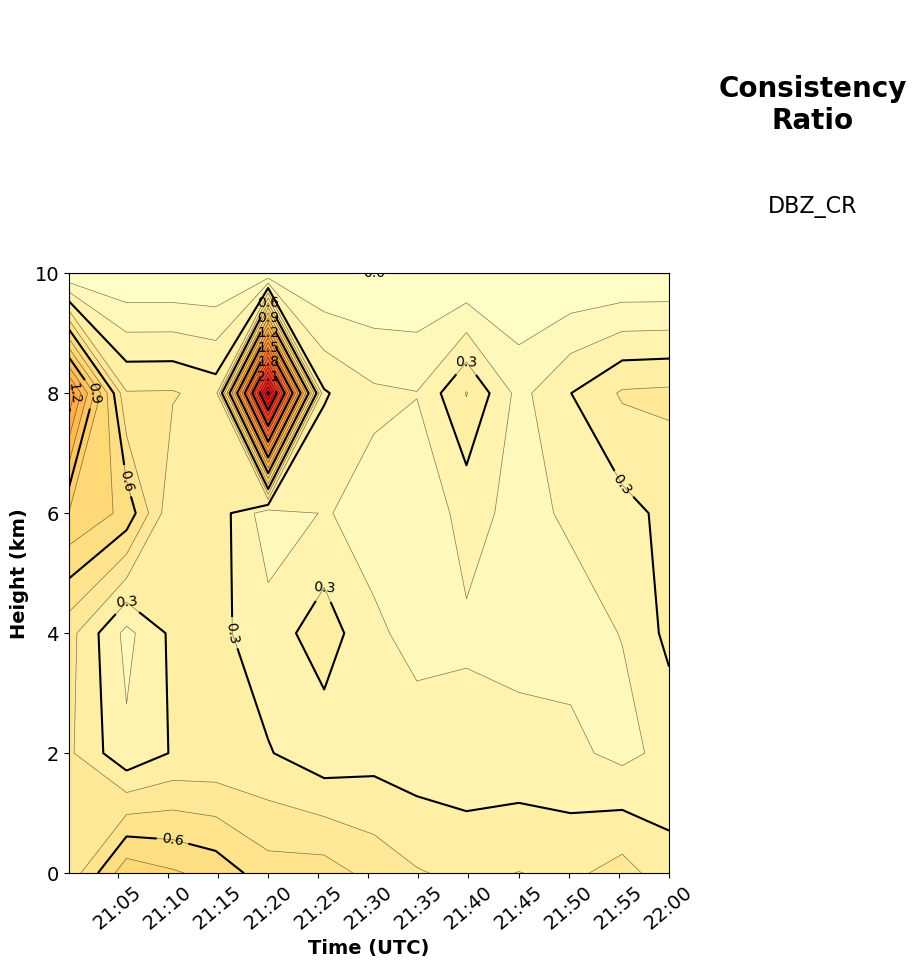

In [5]:
_cmin, _cmax = 0.0, 1.1   # limits for the single line plots...

variable = "VR"   # valid variables:  VR, DBZ
variable = 11   # valid variables:  VR, DBZ

sec_utime = "seconds since 1970-01-01 00:00:00"
auto_clevels = True

# definitions for the plot layout with multiple panels
left, width = 0.1, 0.5
bottom, height = 0.1, 0.5
bottom_h = left_h = left+width+0.03

rectC = [left, bottom, width, height]
rectX = [left, bottom_h, width, 0.2]
rectY = [left_h, bottom, 0.2, height]

fig = P.figure(figsize=(12,12))
fig.text(0.72, 0.72, "\n\nConsistency\nRatio", size=20, va="baseline", ha="center", multialignment="center", weight='bold')
fig.text(0.72, 0.65, plotfilename, size=16, va="baseline", ha="center", multialignment="center")


axC = P.axes(rectC)

zmin, zmax, cint = nice_mxmnintvl(zbins.min()/1000., zbins.max()/1000., outside=True, cint=1.0)
zmin = 0.0

if auto_clevels:
    cmin, cmax, cint, clevels = nice_clevels(0, 3, outside=False, cint = 0.1)
else:
    clevels = np.arange(spread_limits[0], spread_limits[1], spread_limits[2])

cs1=axC.contourf(datebins, zbins/1000., CR_TZ, clevels, cmap=cm.get_cmap('YlOrRd'))
axC.contour(datebins,  zbins/1000., CR_TZ, clevels, colors='k', linewidths=0.5, alpha=0.5)
cs2=axC.contour(datebins,  zbins/1000., CR_TZ, cs1.levels[::3], colors='k')

start = datebins[0]
end   = datebins[-1]

nticks_approx = 8
minute_interval = 5*round((end-start).seconds/(nticks_approx*60*5)) #find the best interval divisble by 5 based on nticks

axC.set_xlim(start, end)
axC.set_ylim(zmin,zmax)

maj_loc = mdates.MinuteLocator(interval=minute_interval)
axC.xaxis.set_major_locator(maj_loc)
dateFmt = mdates.DateFormatter('%H:%M')
axC.xaxis.set_major_formatter(dateFmt)

labels = axC.get_xticklabels()
P.setp(labels, rotation=40, fontsize=14)

axC.clabel(cs2, inline=1, fontsize=10, fmt="%1.1f")
axC.set_ylabel("Height (km)", weight='bold')
axC.set_xlabel("Time (UTC)",weight='bold')

# ens stuff